# Time Series Classification with Pirate Pain X_train_df


## ⚙️ Libraries Import


In [2]:
!pip install --upgrade tensorflow tensorboard
!pip install --upgrade protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.6/620.6 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 94.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 90.6 MB/s eta 0:00:00:00:01
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.0
    Uninstalling tensorflow-2.18.0:
      Successfully uninstalled tensorflow-2.18.0
ERROR: p

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import scipy.sparse as sps
import copy
import shutil
from datetime import datetime
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
import random
import torch
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
from typing import List, Dict
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## ⏳ Data Loading


In [8]:
dataset = pd.read_csv('/kaggle/input/the-pirate-pain-dataset/pirate_pain_test.csv')
userID = pd.read_csv('/kaggle/input/the-pirate-pain-dataset/pirate_pain_train_labels.csv')
validationset = pd.read_csv('/kaggle/input/the-pirate-pain-dataset/pirate_pain_train.csv')

dataset.drop('n_legs', axis=1, inplace=True)
dataset.drop('n_hands', axis=1, inplace=True)
dataset.drop('n_eyes', axis=1, inplace=True)
dataset.drop('pain_survey_1', axis=1, inplace=True)
dataset.drop('pain_survey_2', axis=1, inplace=True)
dataset.drop('pain_survey_3', axis=1, inplace=True)
dataset.drop('pain_survey_4', axis=1, inplace=True)
dataset.drop("joint_30", axis=1, inplace=True)

validationset.drop('n_legs', axis=1, inplace=True)
validationset.drop('n_hands', axis=1, inplace=True)
validationset.drop('n_eyes', axis=1, inplace=True)
validationset.drop('pain_survey_1', axis=1, inplace=True)
validationset.drop('pain_survey_2', axis=1, inplace=True)
validationset.drop('pain_survey_3', axis=1, inplace=True)
validationset.drop('pain_survey_4', axis=1, inplace=True)
validationset.drop("joint_30", axis=1, inplace=True)

## Data visualization and preprocessing

--- CONTINUOUS FEATURE EXPLORATORY DATA ANALYSIS (EDA) ---

Analyzing 31 Continuous Features: ['time', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29']


==================== FEATURE: time ====================
- Unique Values       : 160.0000
- Non-Null Count      : 211840.0000
- Mean                : 79.5000
- Variance            : 2133.2601
- Standard Deviation  : 46.1872
- Min Value           : 0.0000
- Max Value           : 159.0000
- Skewness            : 0.0000

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (2133.26) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


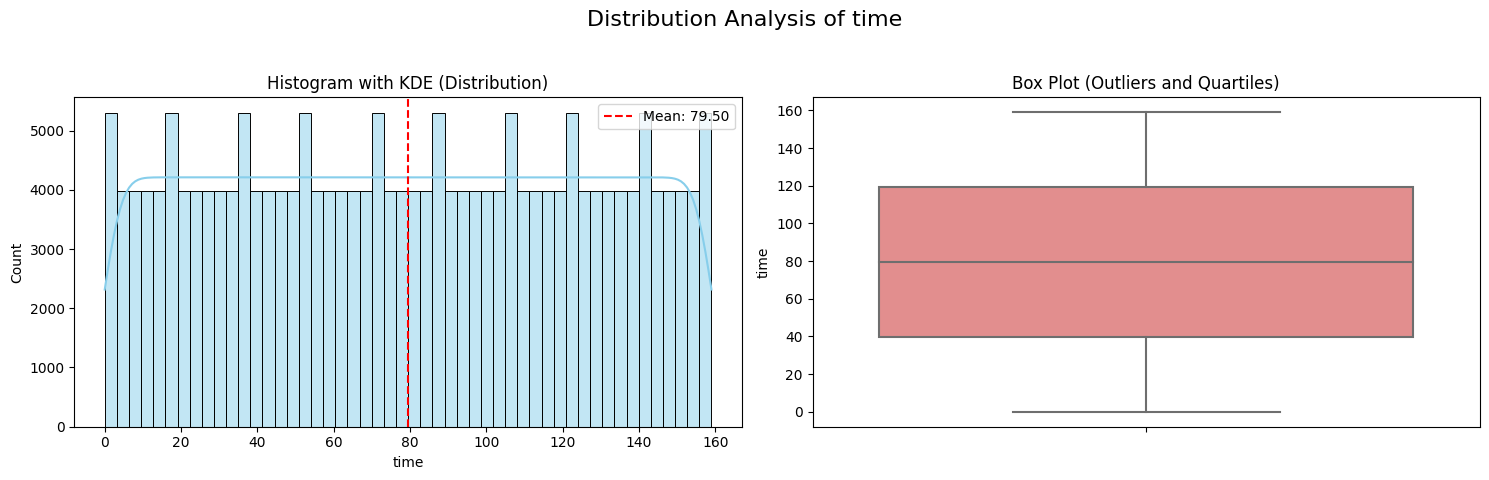


==================== FEATURE: joint_00 ====================
- Unique Values       : 211808.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.9841
- Variance            : 0.0419
- Standard Deviation  : 0.2047
- Min Value           : 0.0000
- Max Value           : 1.5003
- Skewness            : -1.0299

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is -1.03. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


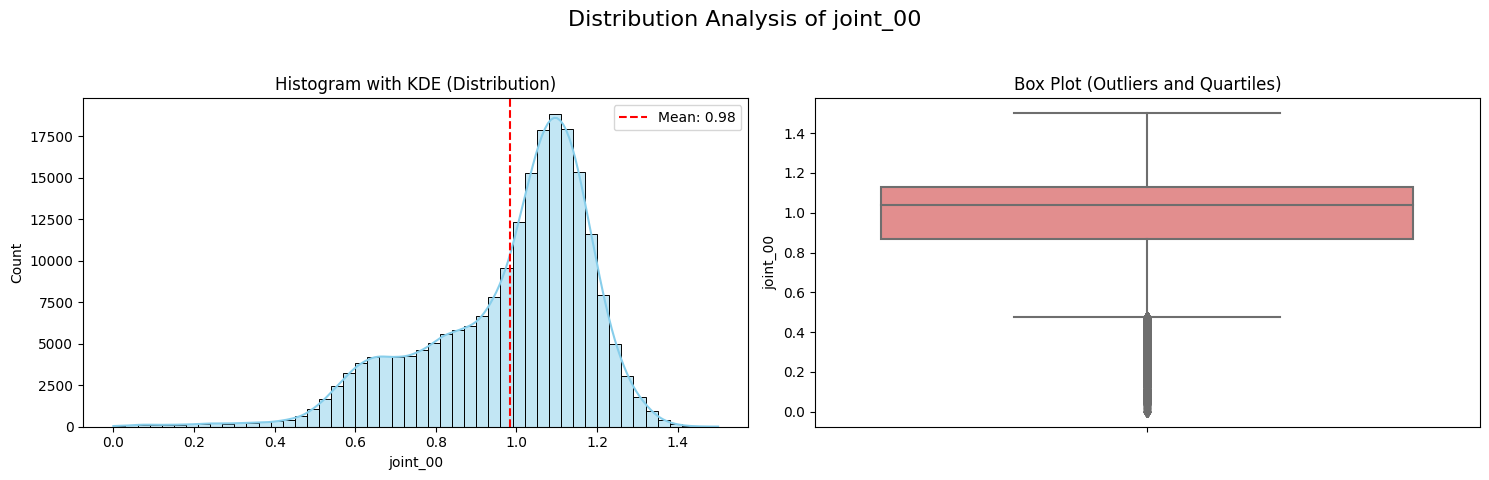


==================== FEATURE: joint_01 ====================
- Unique Values       : 211822.0000
- Non-Null Count      : 211840.0000
- Mean                : 1.0023
- Variance            : 0.0365
- Standard Deviation  : 0.1912
- Min Value           : 0.0368
- Max Value           : 1.4990
- Skewness            : -1.1677

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is -1.17. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


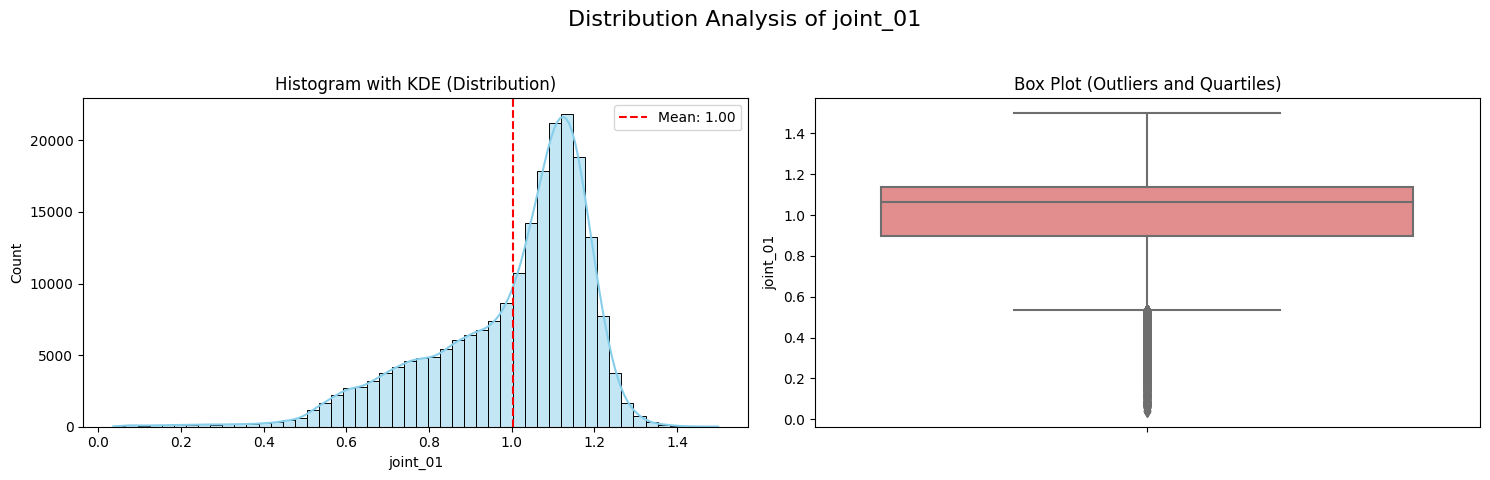


==================== FEATURE: joint_02 ====================
- Unique Values       : 211365.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.8337
- Variance            : 0.0891
- Standard Deviation  : 0.2985
- Min Value           : 0.0148
- Max Value           : 1.3470
- Skewness            : -0.9906

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.09) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


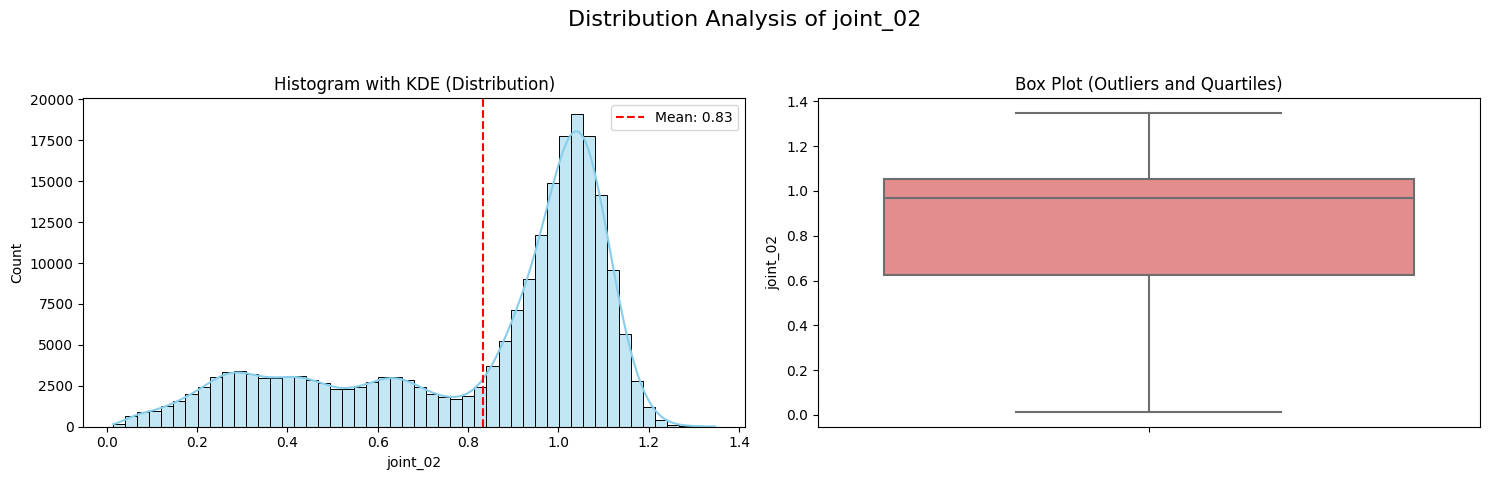


==================== FEATURE: joint_03 ====================
- Unique Values       : 211835.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.8400
- Variance            : 0.0891
- Standard Deviation  : 0.2986
- Min Value           : 0.0476
- Max Value           : 1.3339
- Skewness            : -0.9322

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.09) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


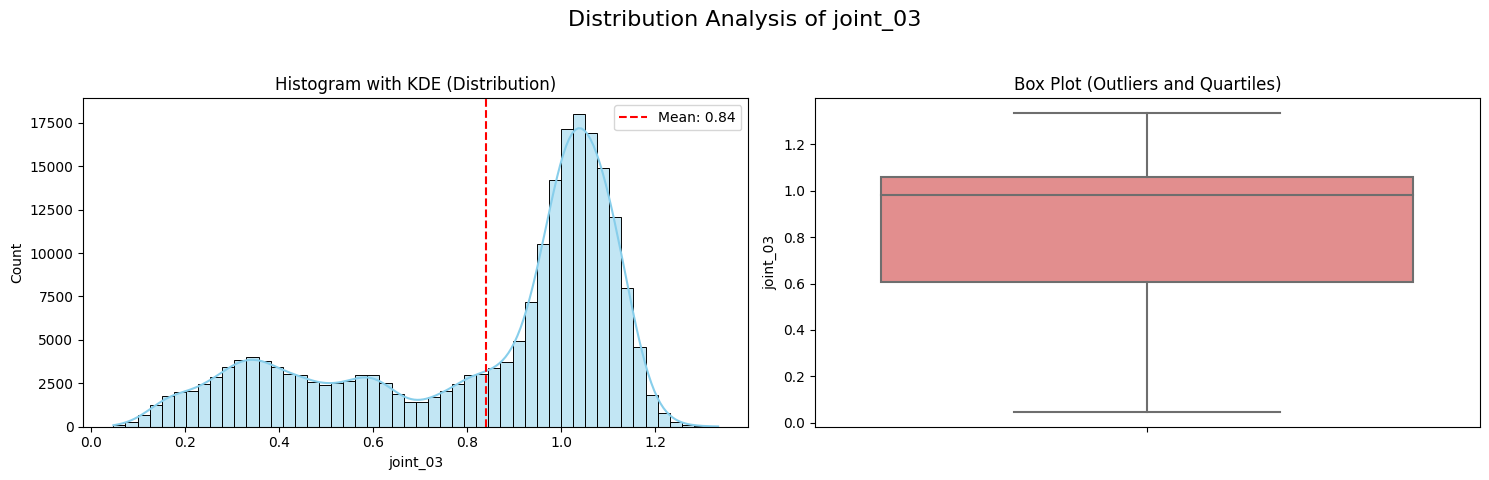


==================== FEATURE: joint_04 ====================
- Unique Values       : 204464.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.7275
- Variance            : 0.1732
- Standard Deviation  : 0.4161
- Min Value           : 0.0000
- Max Value           : 1.4206
- Skewness            : -0.6584

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.17) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


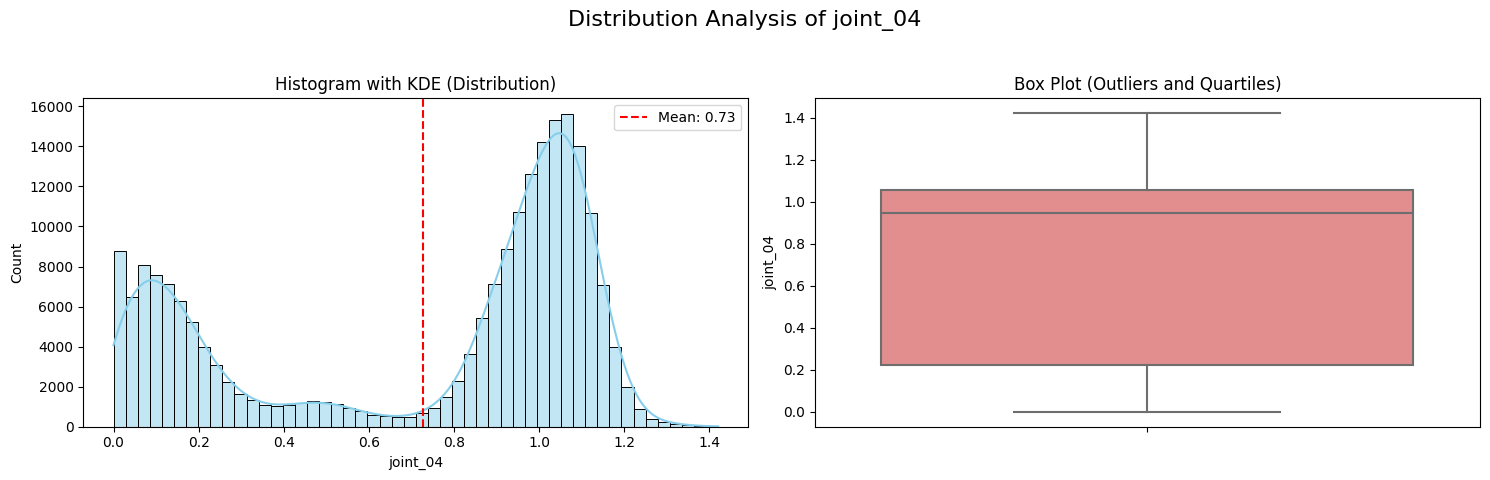


==================== FEATURE: joint_05 ====================
- Unique Values       : 209734.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.7702
- Variance            : 0.1624
- Standard Deviation  : 0.4030
- Min Value           : 0.0013
- Max Value           : 1.4210
- Skewness            : -0.6827

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.16) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


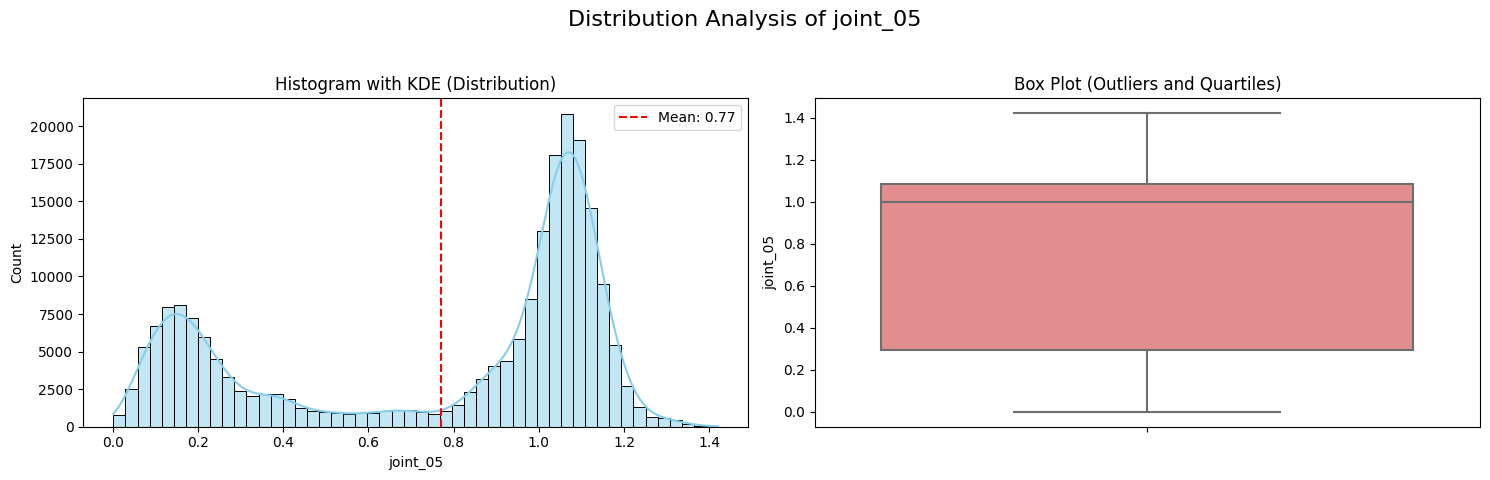


==================== FEATURE: joint_06 ====================
- Unique Values       : 209992.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.8910
- Variance            : 0.0552
- Standard Deviation  : 0.2349
- Min Value           : 0.0000
- Max Value           : 1.4472
- Skewness            : -1.8095

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is -1.81. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


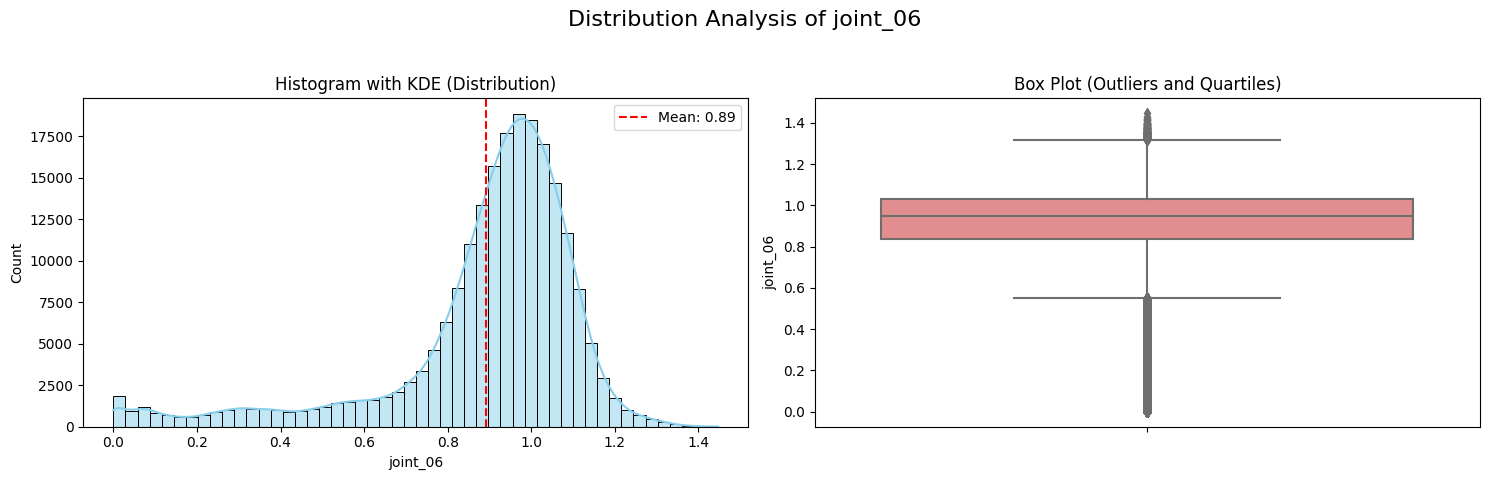


==================== FEATURE: joint_07 ====================
- Unique Values       : 211498.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.8889
- Variance            : 0.0553
- Standard Deviation  : 0.2351
- Min Value           : 0.0000
- Max Value           : 1.4522
- Skewness            : -1.6285

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is -1.63. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


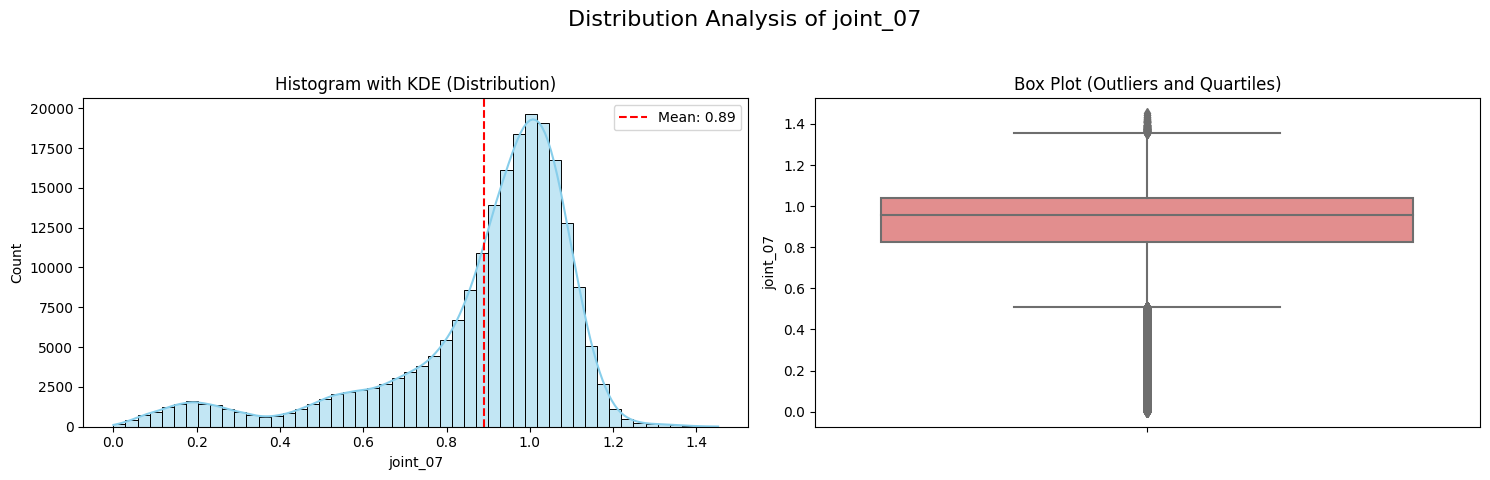


==================== FEATURE: joint_08 ====================
- Unique Values       : 211840.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.9045
- Variance            : 0.0363
- Standard Deviation  : 0.1904
- Min Value           : 0.0329
- Max Value           : 1.4210
- Skewness            : -0.2195

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.04) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


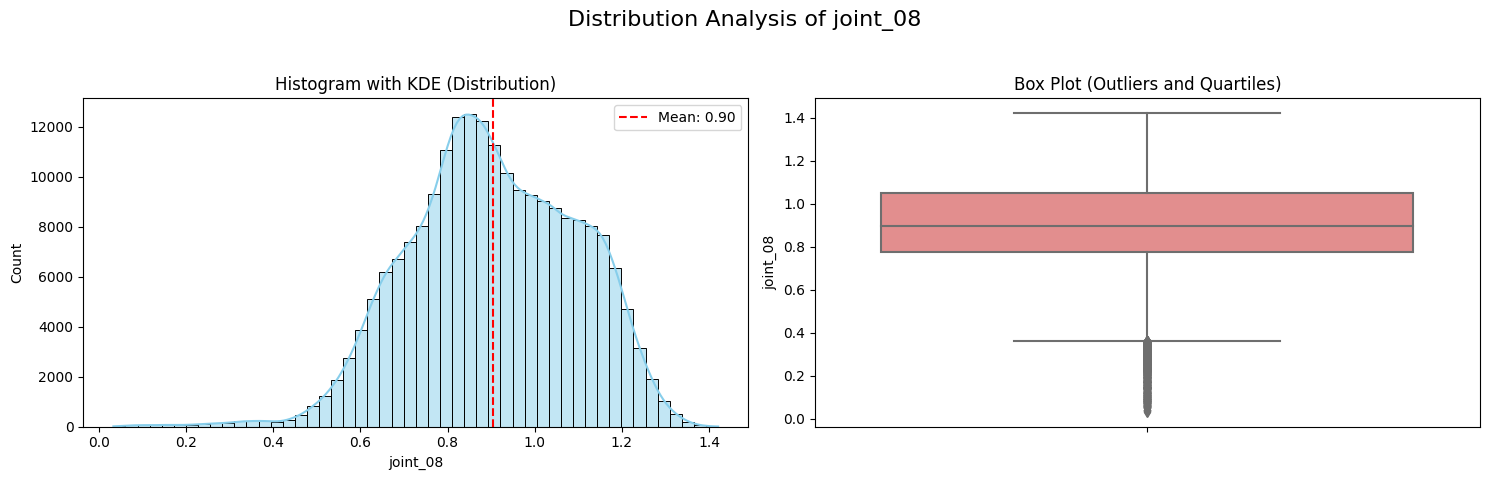


==================== FEATURE: joint_09 ====================
- Unique Values       : 211786.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.9393
- Variance            : 0.0322
- Standard Deviation  : 0.1796
- Min Value           : 0.0000
- Max Value           : 1.4294
- Skewness            : -1.0555

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is -1.06. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


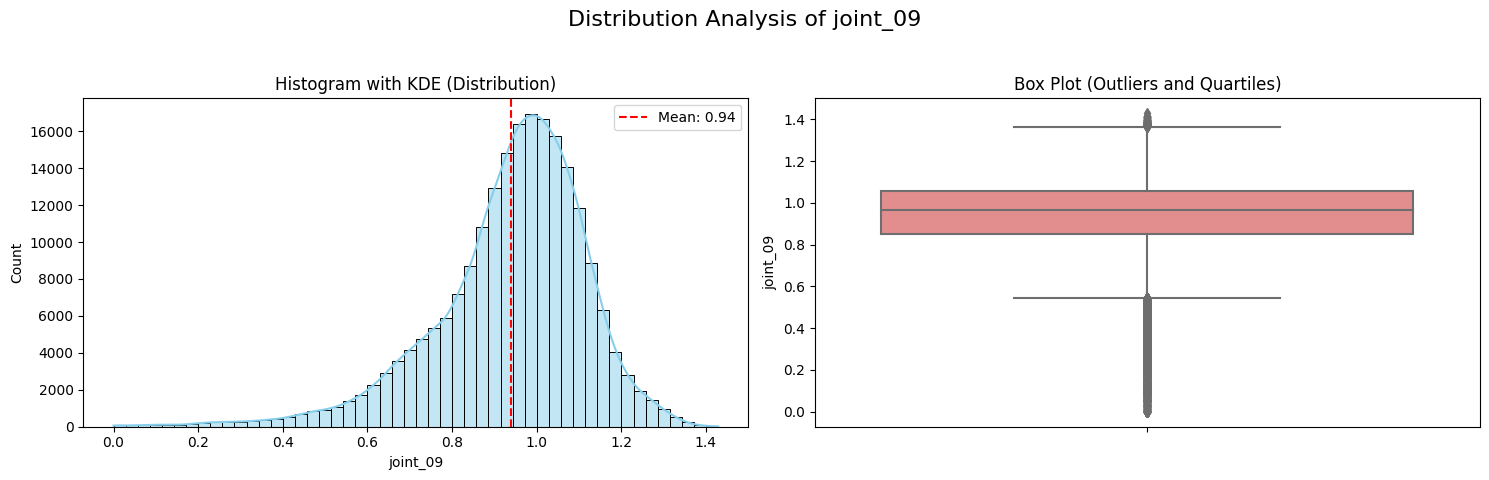


==================== FEATURE: joint_10 ====================
- Unique Values       : 211840.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.7513
- Variance            : 0.0625
- Standard Deviation  : 0.2500
- Min Value           : 0.1957
- Max Value           : 1.5126
- Skewness            : 0.2932

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.06) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


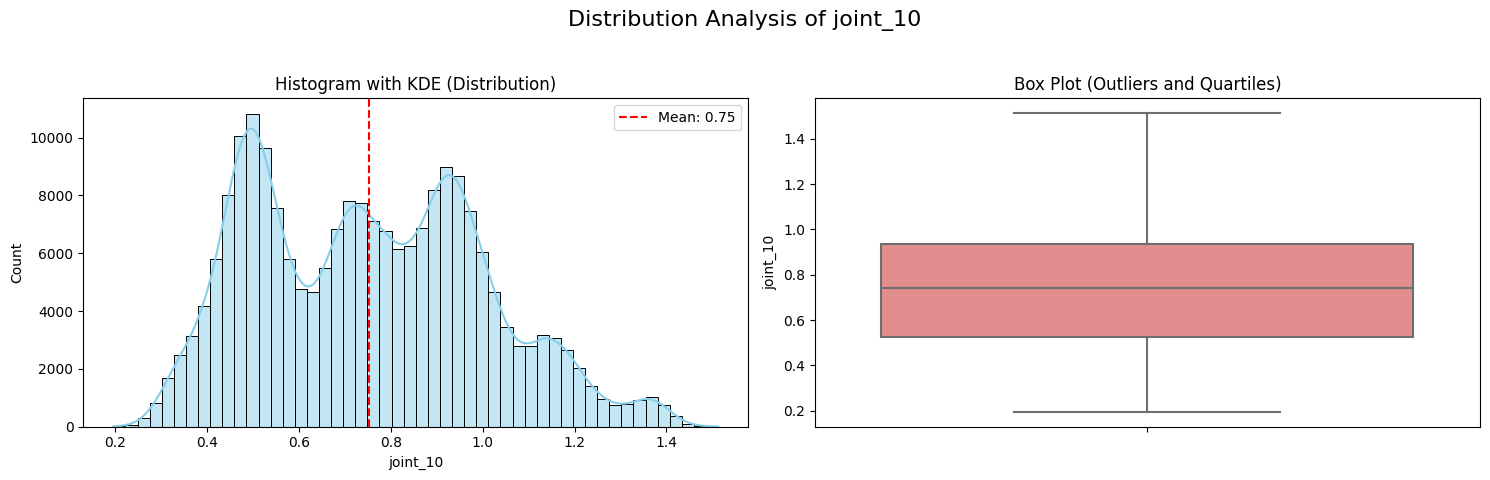


==================== FEATURE: joint_11 ====================
- Unique Values       : 211840.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.7243
- Variance            : 0.0610
- Standard Deviation  : 0.2469
- Min Value           : 0.0391
- Max Value           : 1.5010
- Skewness            : 0.1870

[Usefulness Analysis]
  -> MEDIUM/HIGH USEFULNESS: Good variance (0.06) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


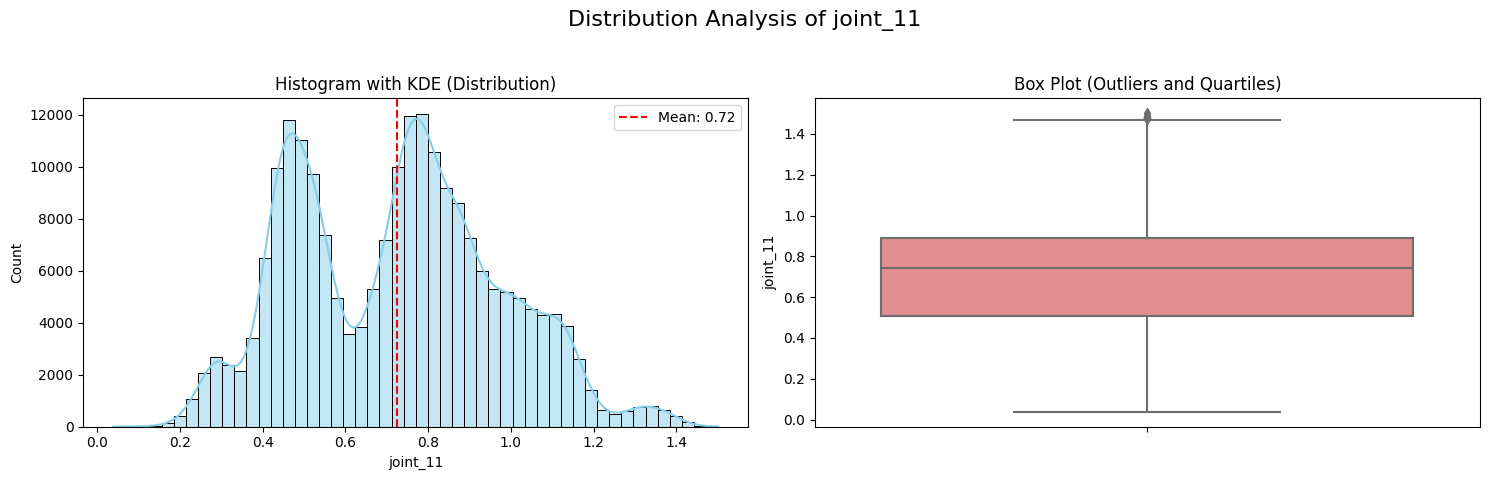


==================== FEATURE: joint_12 ====================
- Unique Values       : 211840.0000
- Non-Null Count      : 211840.0000
- Mean                : 1.1203
- Variance            : 0.0138
- Standard Deviation  : 0.1176
- Min Value           : 0.2327
- Max Value           : 1.5003
- Skewness            : -1.2129

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is -1.21. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


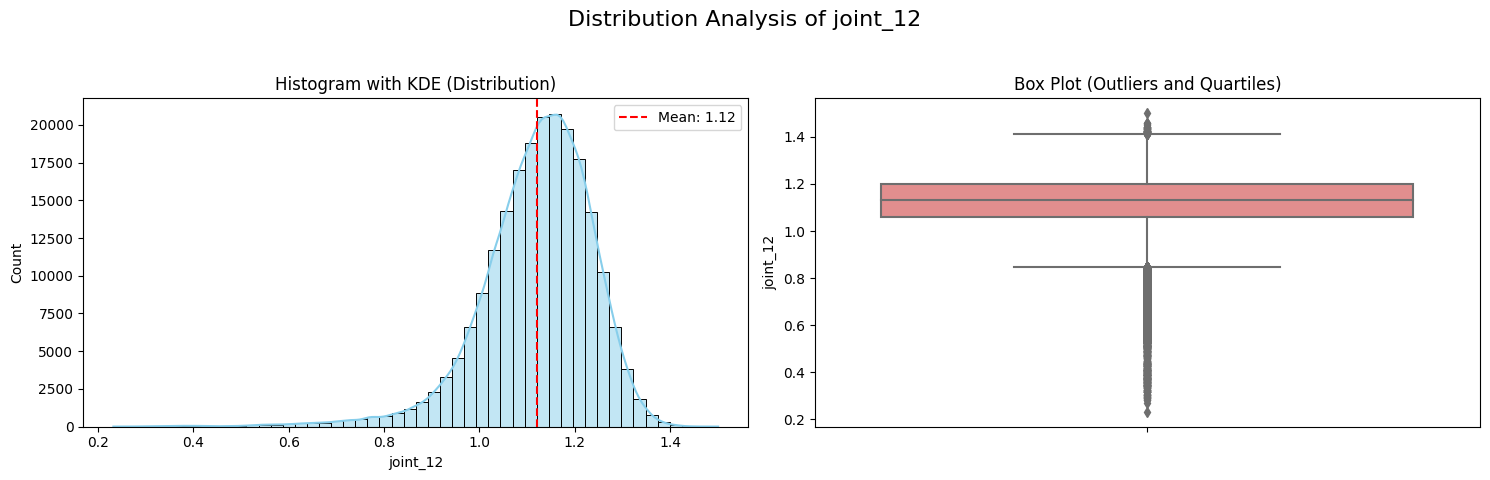


==================== FEATURE: joint_13 ====================
- Unique Values       : 132229.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0001
- Variance            : 0.0000
- Standard Deviation  : 0.0013
- Min Value           : 0.0000
- Max Value           : 0.1701
- Skewness            : 55.4775

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 55.48. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


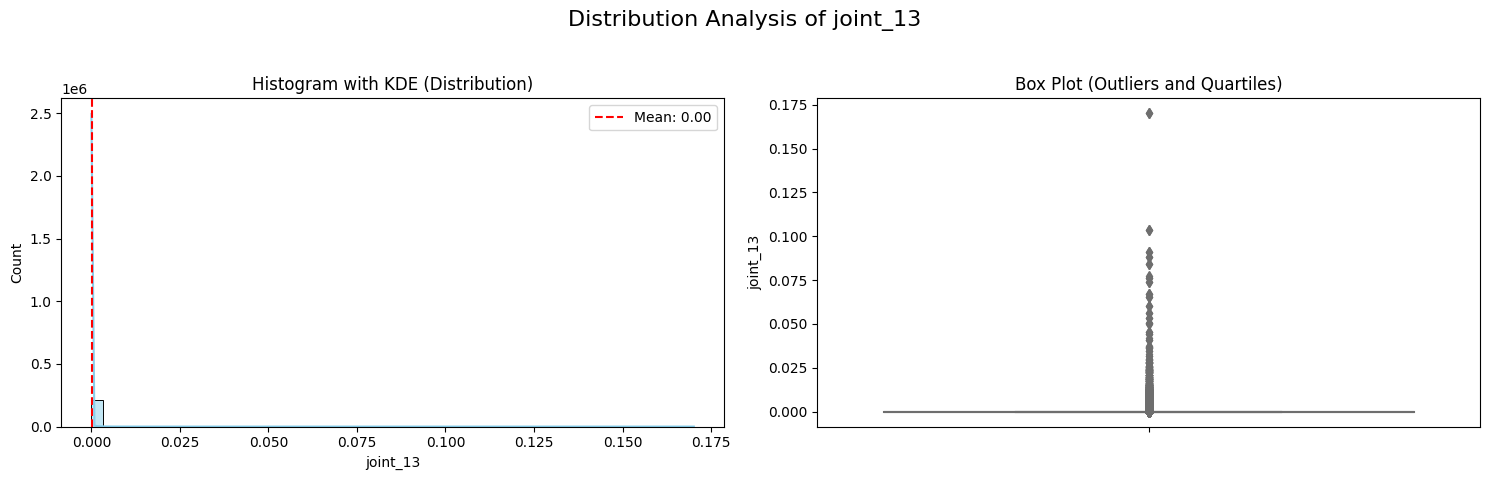


==================== FEATURE: joint_14 ====================
- Unique Values       : 133445.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0001
- Variance            : 0.0000
- Standard Deviation  : 0.0011
- Min Value           : 0.0000
- Max Value           : 0.1255
- Skewness            : 52.5850

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 52.58. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


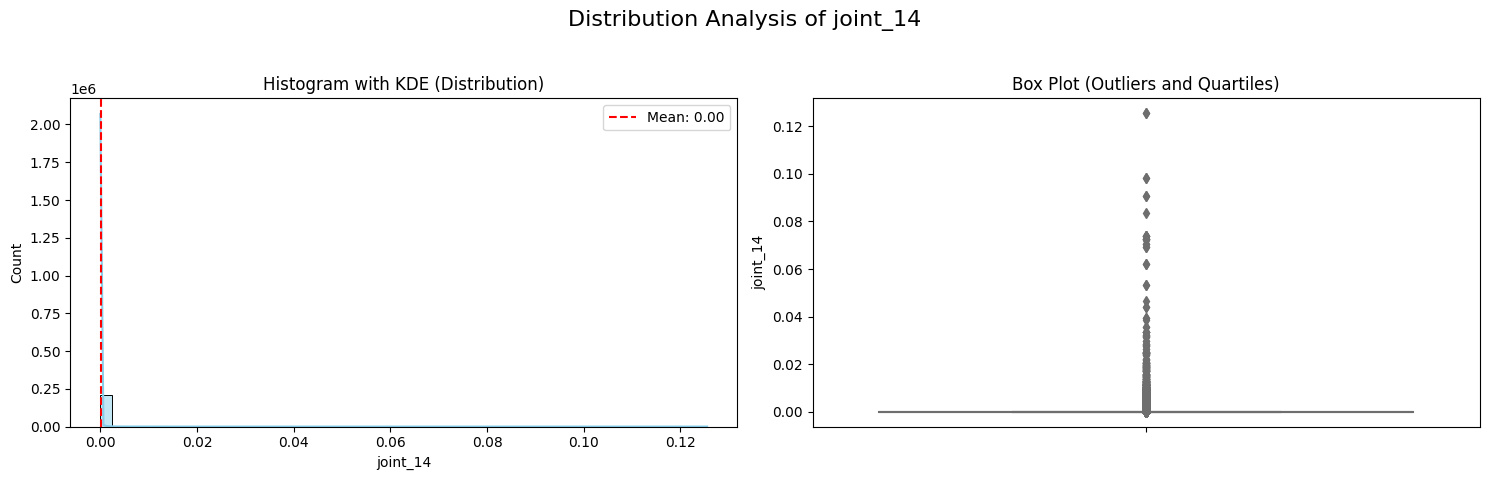


==================== FEATURE: joint_15 ====================
- Unique Values       : 126381.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0001
- Variance            : 0.0000
- Standard Deviation  : 0.0018
- Min Value           : 0.0000
- Max Value           : 0.3148
- Skewness            : 71.5486

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 71.55. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


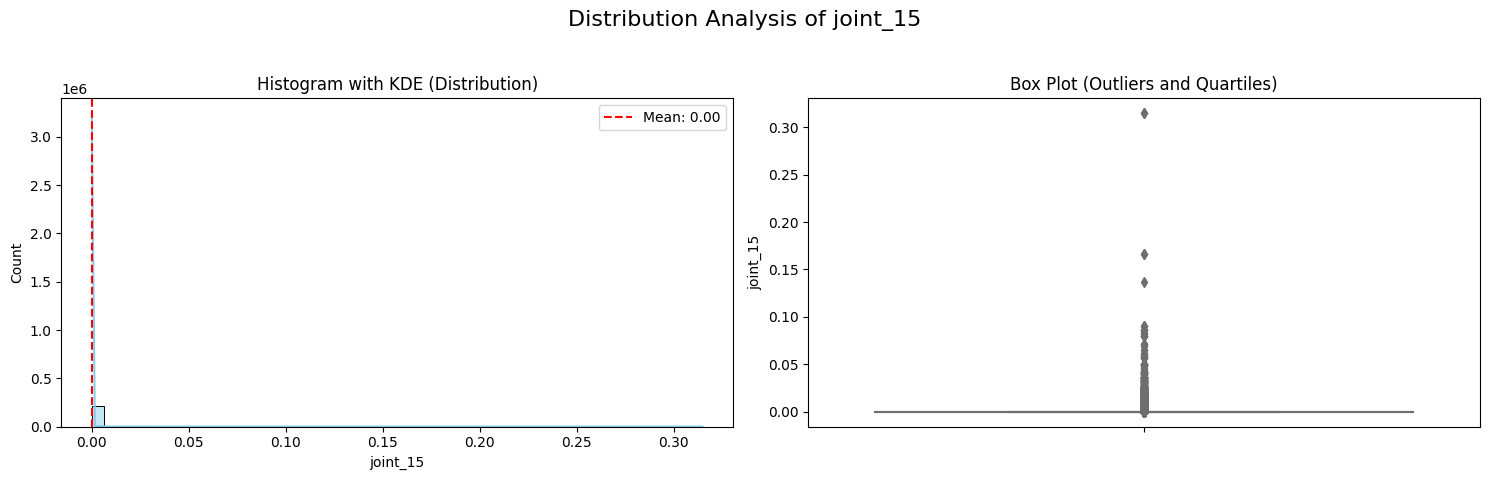


==================== FEATURE: joint_16 ====================
- Unique Values       : 103827.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0001
- Variance            : 0.0000
- Standard Deviation  : 0.0018
- Min Value           : 0.0000
- Max Value           : 0.3325
- Skewness            : 87.2526

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 87.25. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


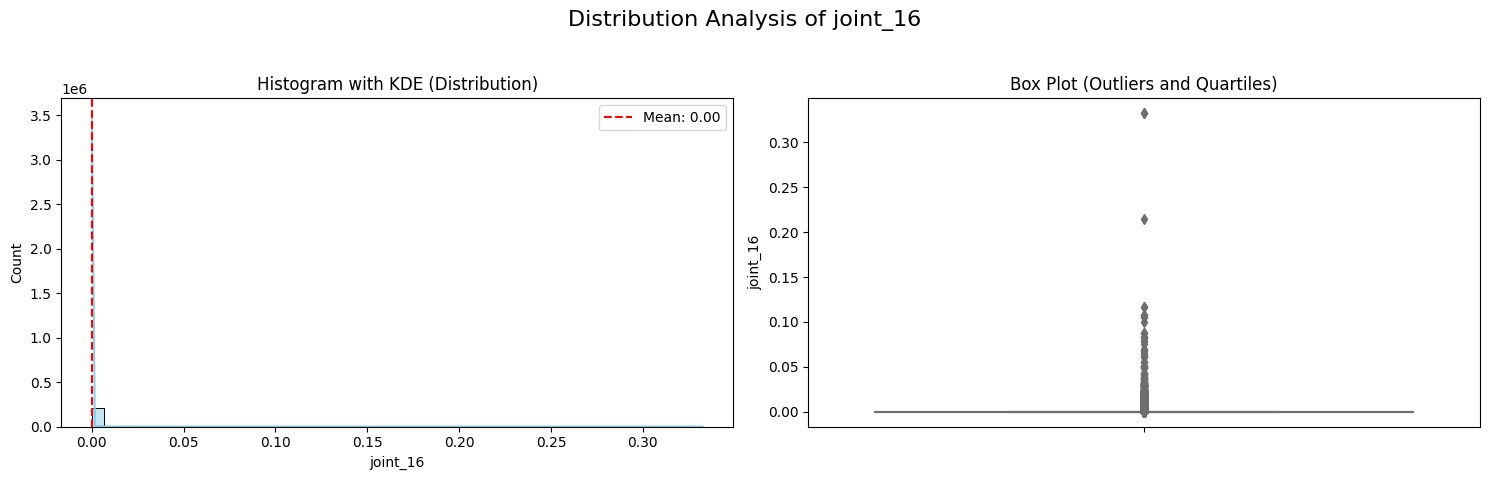


==================== FEATURE: joint_17 ====================
- Unique Values       : 110888.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0004
- Variance            : 0.0000
- Standard Deviation  : 0.0056
- Min Value           : 0.0000
- Max Value           : 0.5276
- Skewness            : 46.7297

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 46.73. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


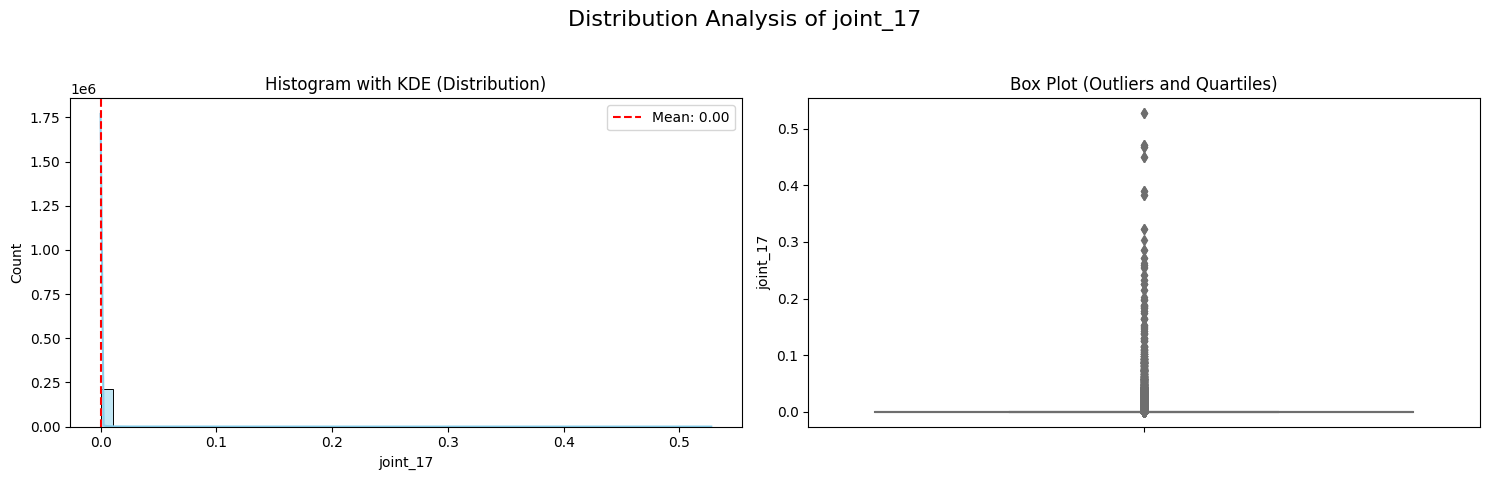


==================== FEATURE: joint_18 ====================
- Unique Values       : 100164.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0003
- Variance            : 0.0000
- Standard Deviation  : 0.0055
- Min Value           : 0.0000
- Max Value           : 1.5103
- Skewness            : 125.6088

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 125.61. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


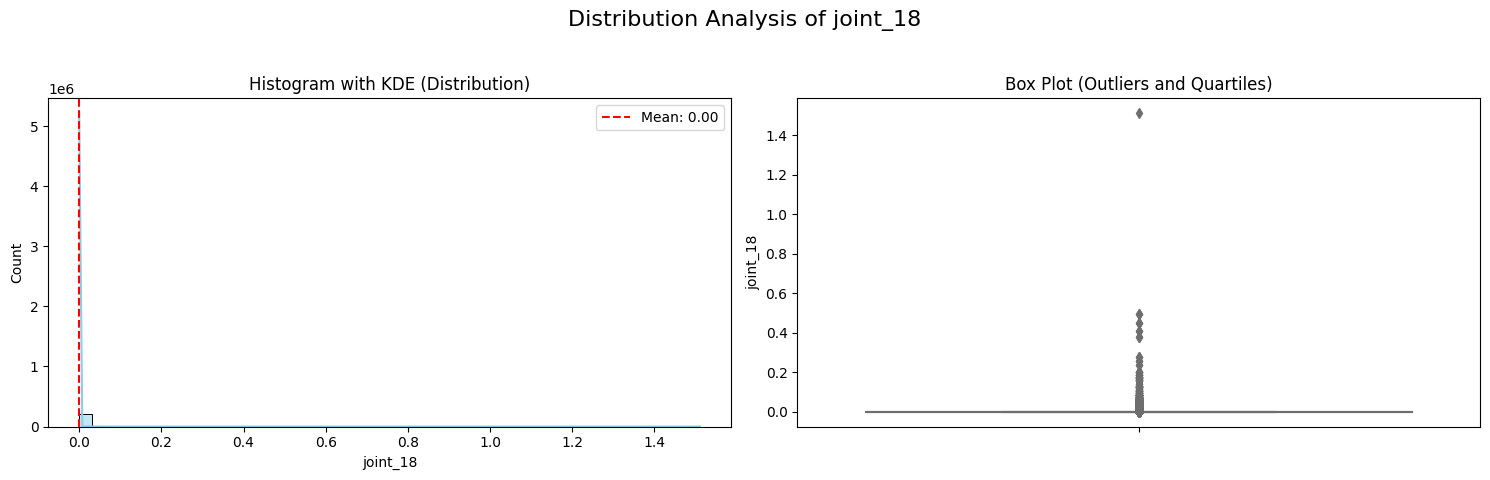


==================== FEATURE: joint_19 ====================
- Unique Values       : 117657.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0003
- Variance            : 0.0001
- Standard Deviation  : 0.0076
- Min Value           : 0.0000
- Max Value           : 1.5531
- Skewness            : 155.1370

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 155.14. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


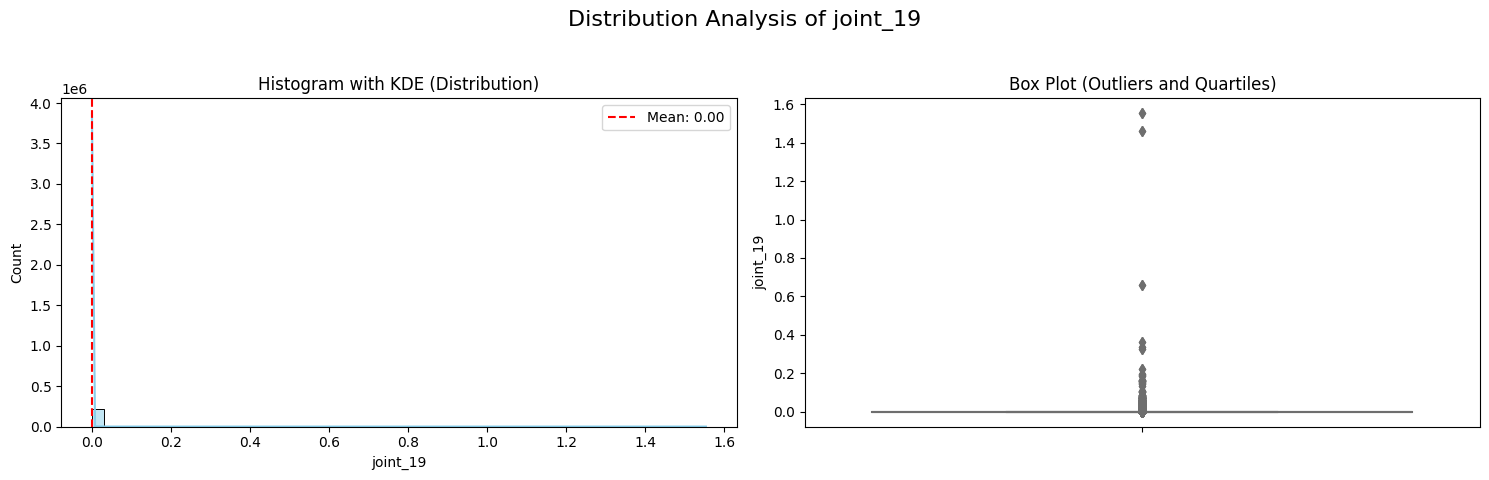


==================== FEATURE: joint_20 ====================
- Unique Values       : 128489.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0004
- Variance            : 0.0001
- Standard Deviation  : 0.0079
- Min Value           : 0.0000
- Max Value           : 1.4378
- Skewness            : 103.6156

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 103.62. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


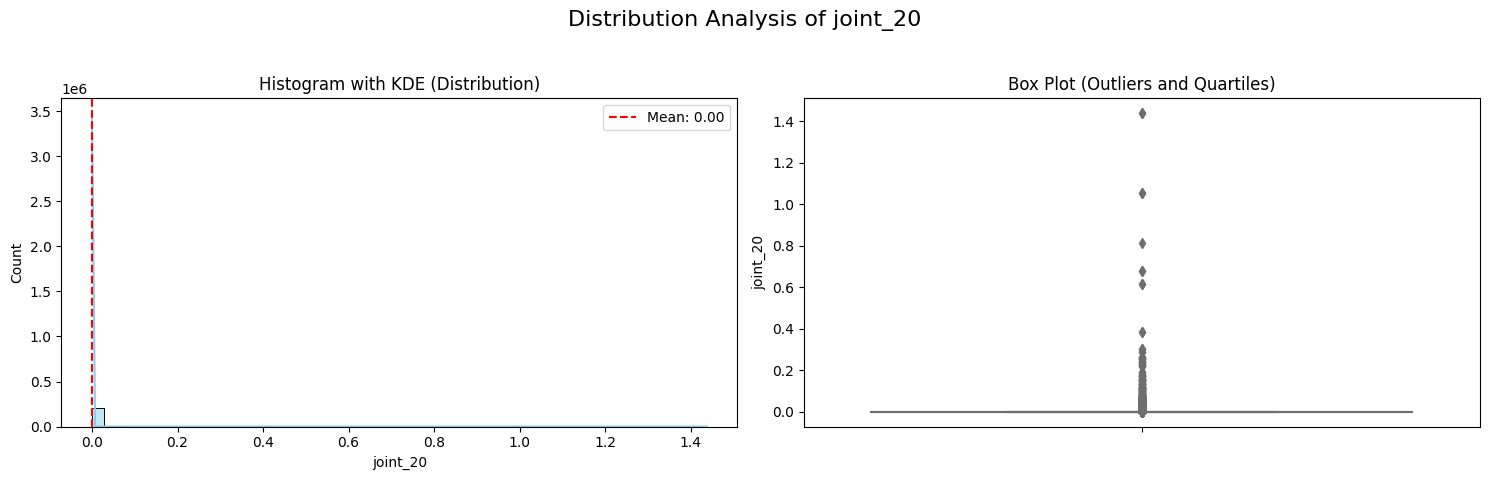


==================== FEATURE: joint_21 ====================
- Unique Values       : 137081.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0000
- Variance            : 0.0000
- Standard Deviation  : 0.0015
- Min Value           : 0.0000
- Max Value           : 0.3899
- Skewness            : 209.1407

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 209.14. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


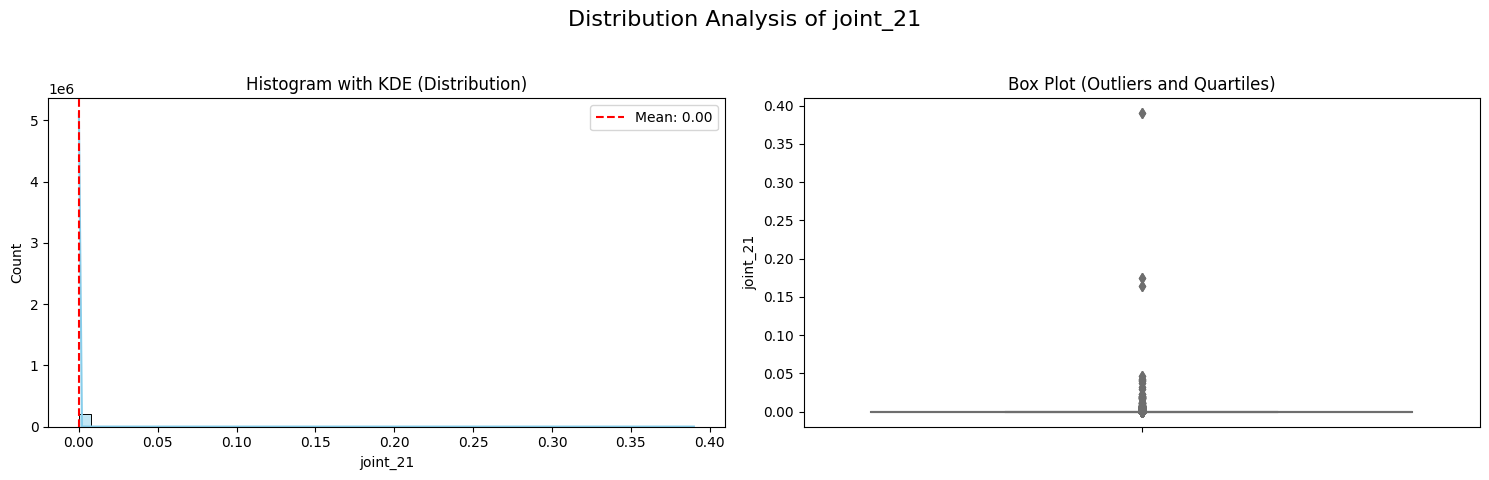


==================== FEATURE: joint_22 ====================
- Unique Values       : 135832.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0000
- Variance            : 0.0000
- Standard Deviation  : 0.0004
- Min Value           : 0.0000
- Max Value           : 0.0628
- Skewness            : 80.3536

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 80.35. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


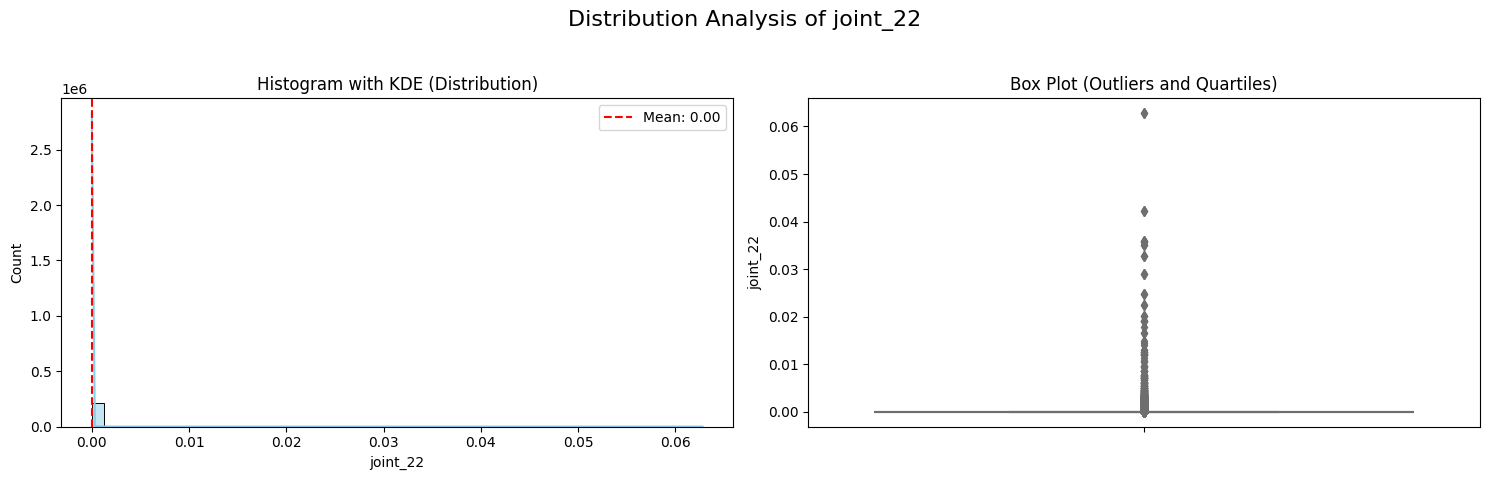


==================== FEATURE: joint_23 ====================
- Unique Values       : 120087.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0000
- Variance            : 0.0000
- Standard Deviation  : 0.0006
- Min Value           : 0.0000
- Max Value           : 0.0648
- Skewness            : 68.1678

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 68.17. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


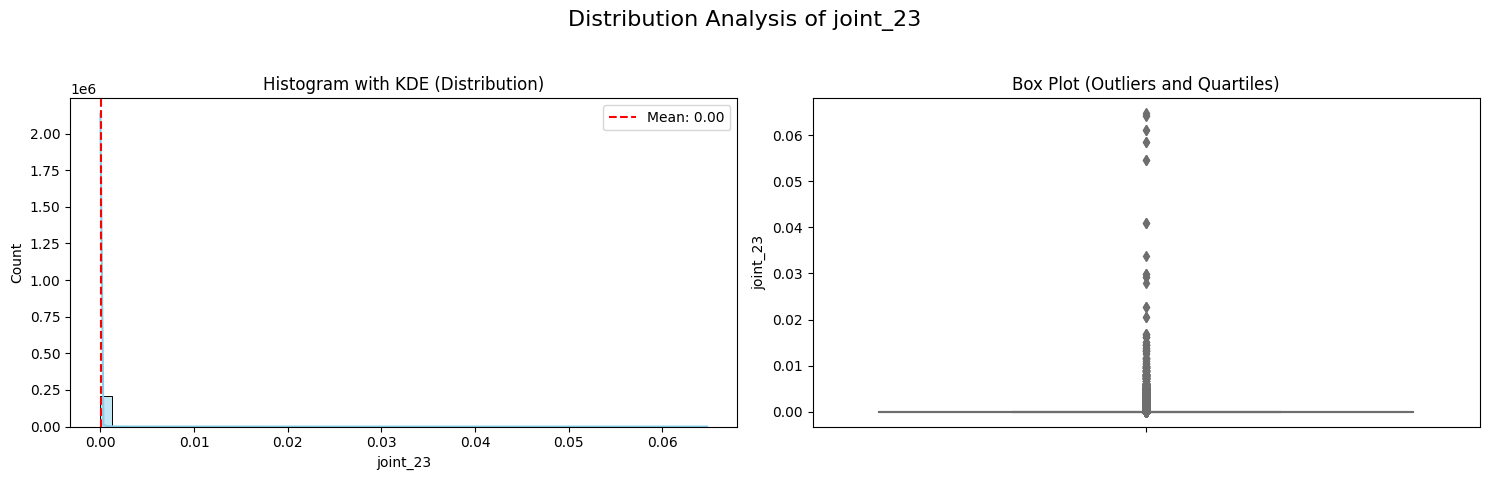


==================== FEATURE: joint_24 ====================
- Unique Values       : 116173.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0000
- Variance            : 0.0000
- Standard Deviation  : 0.0006
- Min Value           : 0.0000
- Max Value           : 0.1250
- Skewness            : 111.0916

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 111.09. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


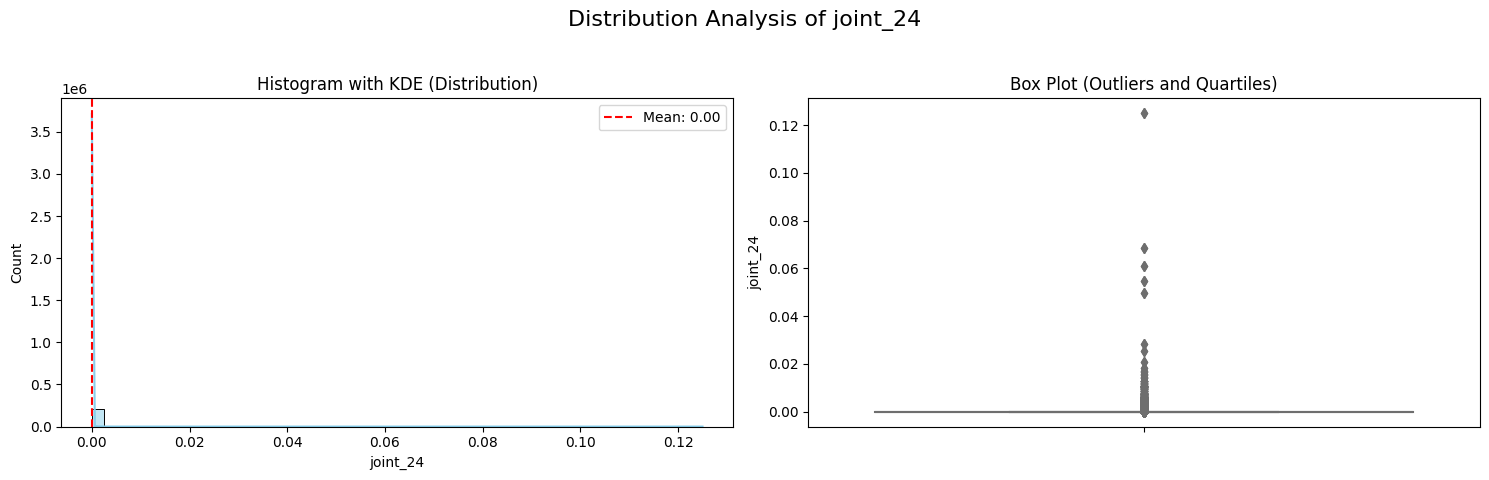


==================== FEATURE: joint_25 ====================
- Unique Values       : 117047.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0001
- Variance            : 0.0000
- Standard Deviation  : 0.0012
- Min Value           : 0.0000
- Max Value           : 0.1673
- Skewness            : 59.0266

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 59.03. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


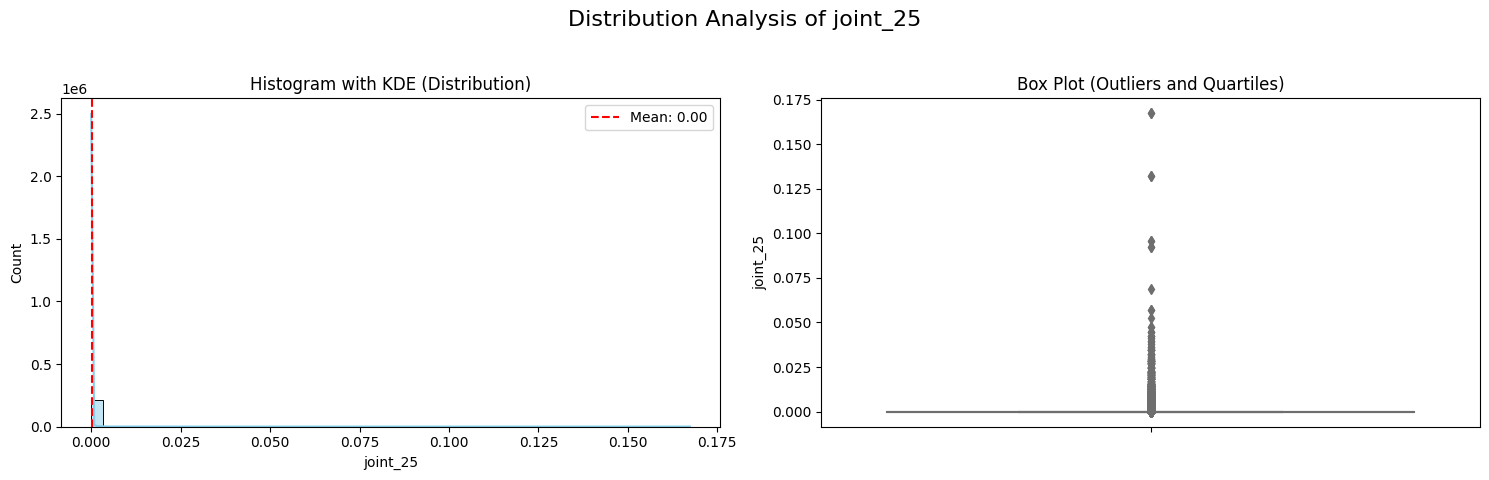


==================== FEATURE: joint_26 ====================
- Unique Values       : 206660.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0405
- Variance            : 0.0033
- Standard Deviation  : 0.0572
- Min Value           : 0.0000
- Max Value           : 1.2993
- Skewness            : 4.5553

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 4.56. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


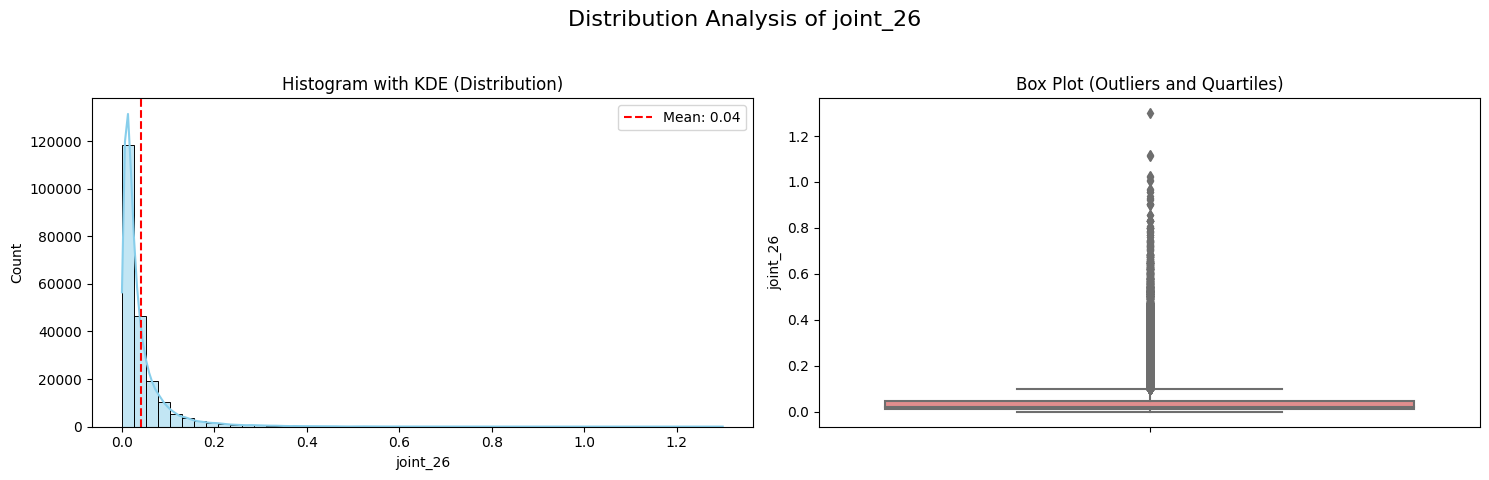


==================== FEATURE: joint_27 ====================
- Unique Values       : 205178.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0601
- Variance            : 0.0061
- Standard Deviation  : 0.0781
- Min Value           : 0.0045
- Max Value           : 1.3759
- Skewness            : 3.7669

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 3.77. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


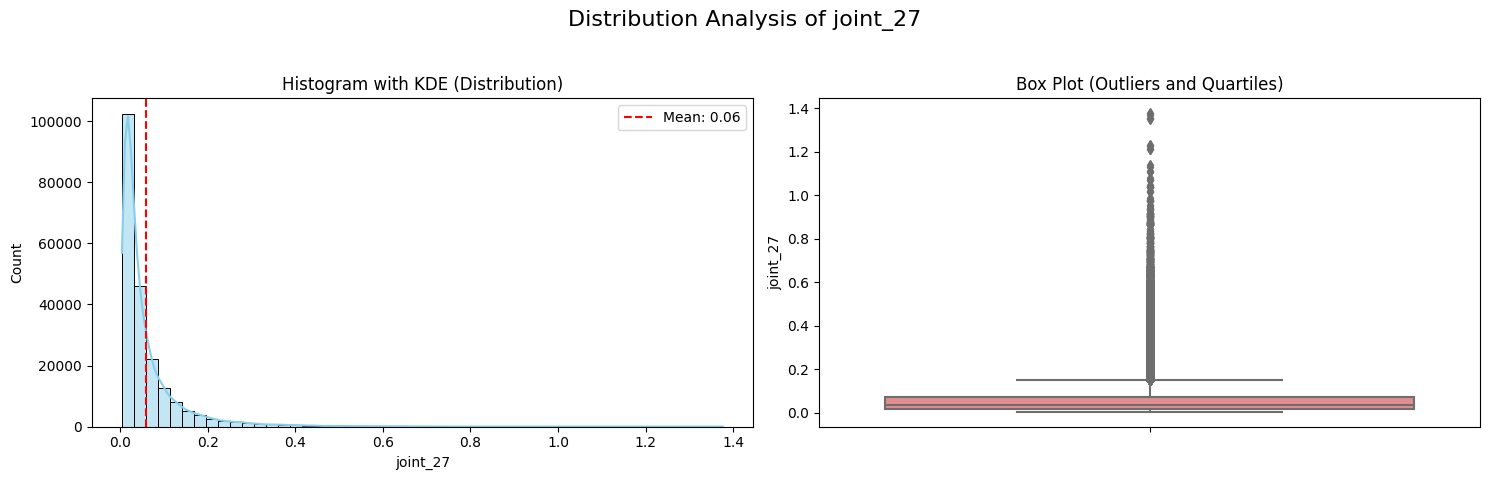


==================== FEATURE: joint_28 ====================
- Unique Values       : 209039.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0525
- Variance            : 0.0034
- Standard Deviation  : 0.0587
- Min Value           : 0.0041
- Max Value           : 1.4126
- Skewness            : 3.9958

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 4.00. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


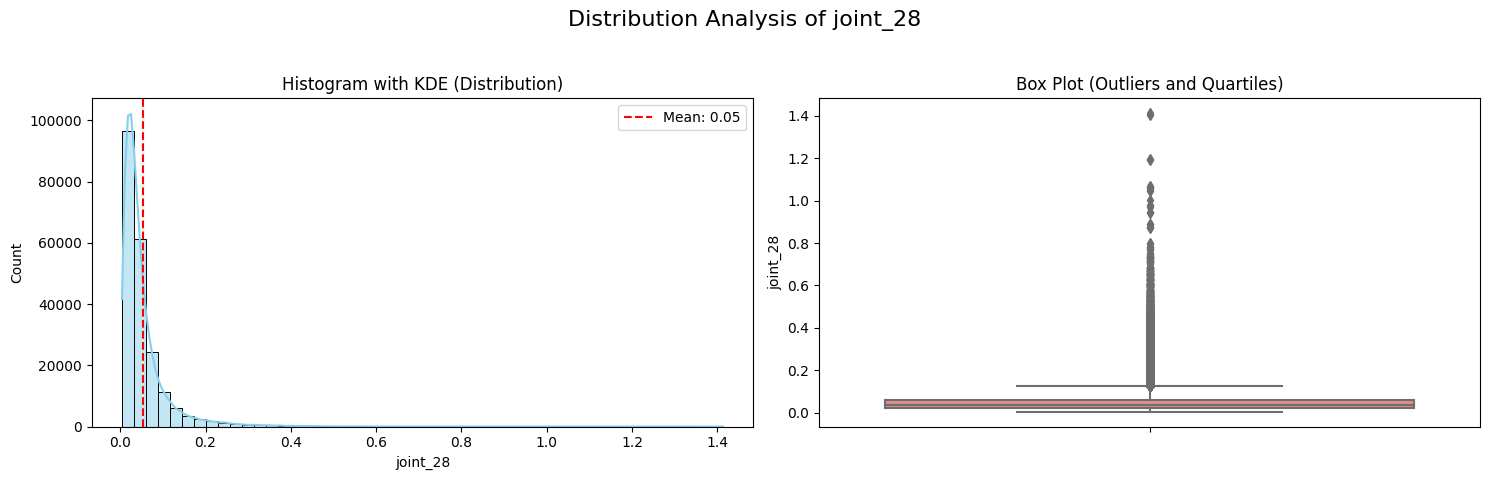


==================== FEATURE: joint_29 ====================
- Unique Values       : 210661.0000
- Non-Null Count      : 211840.0000
- Mean                : 0.0612
- Variance            : 0.0044
- Standard Deviation  : 0.0667
- Min Value           : 0.0000
- Max Value           : 1.3338
- Skewness            : 3.3622

[Usefulness Analysis]
  -> HIGH SKEWNESS: Skewness is 3.36. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


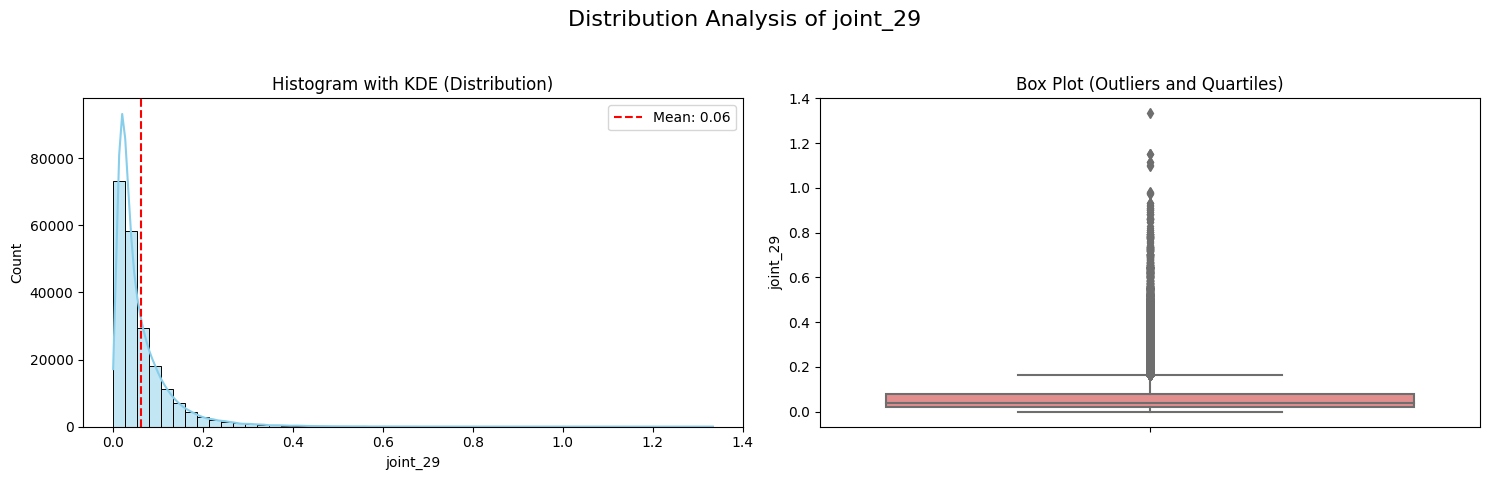


--- EDA Complete ---


In [15]:
def analyze_continuous_features(df: pd.DataFrame, identifier_cols: List[str], cardinality_threshold: int = 20) -> None:
    """
    Analyzes and visualizes continuous features in a DataFrame.

    Args:
        df: The input DataFrame (e.g., dataset).
        identifier_cols: Columns to exclude from analysis (e.g., indices, labels).
        cardinality_threshold: Max unique values for a numerical column to be considered 
                               potentially categorical instead of continuous.
    """
    print("--- CONTINUOUS FEATURE EXPLORATORY DATA ANALYSIS (EDA) ---")
    
    # 1. Identify numerical and continuous columns
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    
    continuous_features = []
    for col in numerical_cols:
        if col in identifier_cols:
            continue
        # Check if the column has high cardinality to be treated as continuous
        if df[col].nunique() > cardinality_threshold:
            continuous_features.append(col)
        else:
            print(f"\n[INFO] Skipping '{col}' (N_Unique={df[col].nunique()}). Treated as low-cardinality/discrete or identifier.")

    if not continuous_features:
        print("\nNo continuous features found for analysis.")
        return

    print(f"\nAnalyzing {len(continuous_features)} Continuous Features: {continuous_features}\n")

    # 2. Loop through and analyze each feature
    for feature in continuous_features:
        print(f"\n==================== FEATURE: {feature} ====================")
        
        # --- Descriptive Statistics ---
        stats = {
            "Unique Values": df[feature].nunique(),
            "Non-Null Count": df[feature].count(),
            "Mean": df[feature].mean(),
            "Variance": df[feature].var(),
            "Standard Deviation": df[feature].std(),
            "Min Value": df[feature].min(),
            "Max Value": df[feature].max(),
            "Skewness": df[feature].skew()
        }
        
        # Print Statistics
        for key, value in stats.items():
            print(f"- {key:<20}: {value:.4f}")

        # --- Usefulness Analysis ---
        print("\n[Usefulness Analysis]")
        
        # A. Check for constant/near-constant features (low variance)
        if stats["Variance"] < 1e-3 and stats["Unique Values"] < len(df) * 0.01:
            print(f"  -> LOW USEFULNESS: Variance ({stats['Variance']:.2e}) is extremely low. This feature is nearly constant across the dataset and likely carries almost no predictive power. Consider dropping it.")
        
        # B. Check for heavy skewness (potential data transformations)
        elif abs(stats["Skewness"]) > 1.0:
            print(f"  -> HIGH SKEWNESS: Skewness is {stats['Skewness']:.2f}. The data is heavily concentrated on one side. A logarithmic or power transformation might be beneficial to normalize the distribution before feeding it to the model.")
        
        # C. General assessment
        else:
            print(f"  -> MEDIUM/HIGH USEFULNESS: Good variance ({stats['Variance']:.2f}) and spread. The feature appears well-distributed and likely useful. Standard scaling (StandardScaler) is recommended.")
            
        
        # --- Visualization ---
        
        # Create a figure with two subplots: Histogram/KDE and Box Plot
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f'Distribution Analysis of {feature}', fontsize=16)

        # Histogram (Distribution)
        sns.histplot(df[feature], kde=True, ax=axes[0], color='skyblue', bins=50)
        axes[0].set_title('Histogram with KDE (Distribution)')
        axes[0].set_xlabel(feature)
        axes[0].axvline(df[feature].mean(), color='red', linestyle='--', label=f'Mean: {stats["Mean"]:.2f}')
        axes[0].legend()

        # Box Plot (Outliers and Quartiles)
        sns.boxplot(y=df[feature], ax=axes[1], color='lightcoral')
        axes[1].set_title('Box Plot (Outliers and Quartiles)')
        axes[1].set_ylabel(feature)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
        plt.show()

# --- EXECUTION ---

# Define the columns that must be excluded (identifiers and target label)
identifier_cols_to_exclude = ['sample_index', 'label']

# Run the analysis on the main DataFrame, excluding only identifiers, and using threshold 5
analyze_continuous_features(dataset, identifier_cols=identifier_cols_to_exclude, cardinality_threshold=5)

print("\n--- EDA Complete ---")

In [9]:
columns = dataset.columns
columns

Index(['sample_index', 'time', 'joint_00', 'joint_01', 'joint_02', 'joint_03',
       'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09',
       'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15',
       'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21',
       'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27',
       'joint_28', 'joint_29'],
      dtype='object')

In [55]:
dataset[columns].describe()

,joint_13,joint_14,joint_15,joint_16,joint_17,joint_18,joint_19,joint_20,joint_21,joint_22,joint_23,joint_24,joint_25
count,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,211840.000000,2.118400e+05,2.118400e+05,211840.000000
mean,0.000099,0.000089,0.000132,0.000115,0.000370,0.000300,0.000269,0.000374,0.000032,0.000024,4.138805e-05,3.408469e-05,0.000107
std,0.001260,0.001120,0.001826,0.001781,0.005643,0.005504,0.007644,0.007861,0.001464,0.000413,5.570593e-04,6.285418e-04,0.001203
min,0.000000,0.000004,0.000004,0.000000,0.000000,0.000000,0.000000,0.000009,0.000002,0.000001,0.000000e+00,0.000000e+00,0.000000
25%,0.000006,0.000007,0.000009,0.000000,0.000007,0.000000,0.000005,0.000026,0.000003,0.000003,4.412668e-07,2.325231e-07,0.000000
50%,0.000009,0.000009,0.000010,0.000006,0.000027,0.000016,0.000015,0.000032,0.000004,0.000004,2.527479e-06,2.060598e-06,0.000006
75%,0.000013,0.000013,0.000015,0.000010,0.000041,0.000030,0.000024,0.000046,0.000006,0.000006,4.590578e-06,3.708785e-06,0.000014
max,0.170132,0.125523,0.314769,0.332521,0.527590,1.510331,1.553126,1.437842,0.389906,0.062781,6.476609e-02,1.249919e-01,0.167318


OKay, Now we got a point, Just focus on the value that are centered, in 0.00!
From Joint 13 to 25

In [49]:
def plot_zoomed_distributions_notebook(
    df: pd.DataFrame, 
    columns_to_plot: List[str], 
    zoom_limit: float = 0.01
):
    """
    Plots a zoomed-in histogram for a specified set of columns in a DataFrame,
    displaying the output directly in a notebook environment.
    """
    
    for column_name in columns_to_plot:
        if column_name in df.columns:
            print(f"Check: Plotting {column_name}") # Use a more informative message
            
            # 1. Create the figure
            plt.figure(figsize=(10, 6))

            # 2. Plot the distribution
            sns.histplot(
                data=df,
                x=column_name,
                bins=50,
                kde=True,
                color='skyblue',
                edgecolor='black'
            )

            # 3. Apply the zoom effect
            plt.xlim(-zoom_limit*2, zoom_limit*2)
            plt.ylim(0, 20000)
            
            # 4. Add titles and labels
            plt.title(
                f'Zoomed Distribution of {column_name}',
                fontsize=16
            )
            plt.xlabel(f'{column_name} Value', fontsize=14)
            plt.ylabel('Count / Density', fontsize=14)
            plt.grid(axis='y', alpha=0.5)
            
            # 5. Display the plot:
            # This is the essential change. plt.show() forces the plot to render 
            # and display immediately, which is crucial when inside a loop or function.
            plt.show() 
            
            # NOTE: plt.close() is no longer strictly needed but can be used 
            # if memory management is a concern, but plt.show() usually handles 
            # the figure lifecycle correctly in notebooks.
            # If you remove plt.show() in a notebook, it often relies on the 
            # final object being the figure, which is lost inside a function/loop.
        else:
            print(f"Warning: Column '{column_name}' not found in the DataFrame. Skipping.")


Check: Plotting joint_13


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


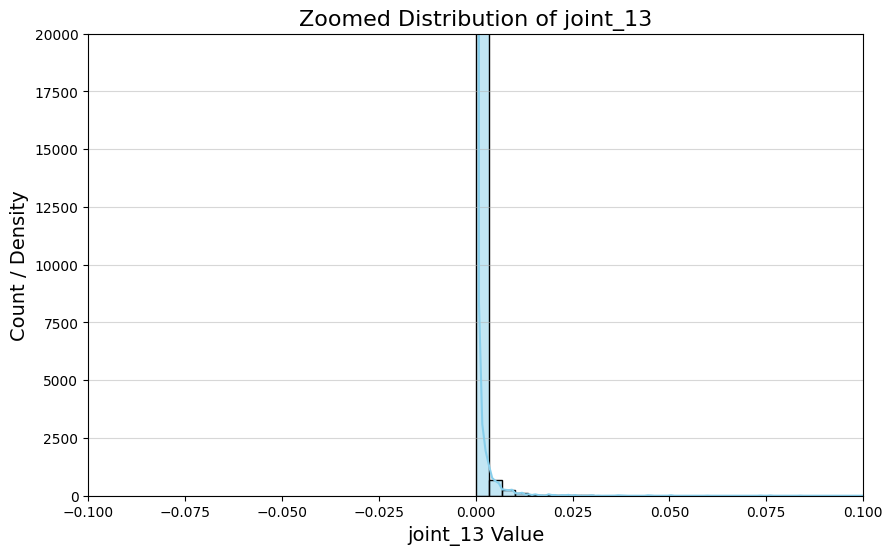

Check: Plotting joint_14


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


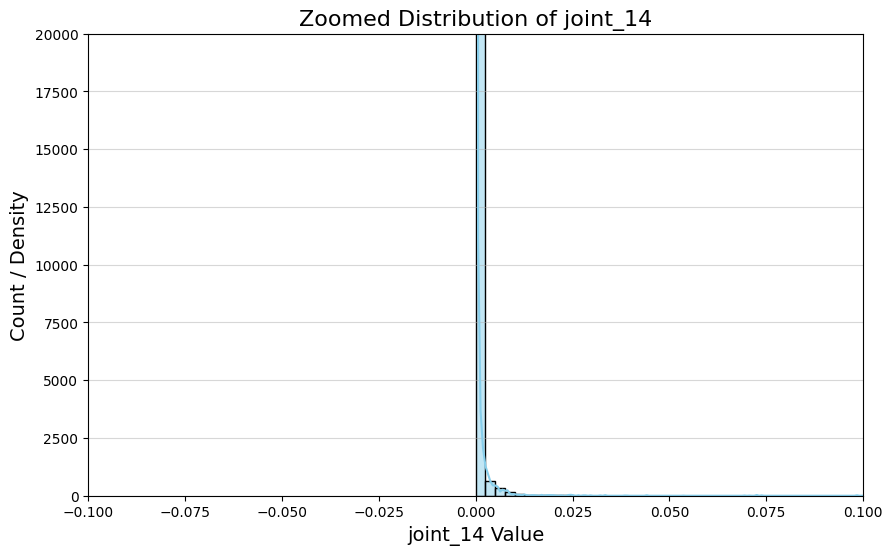

Check: Plotting joint_15


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


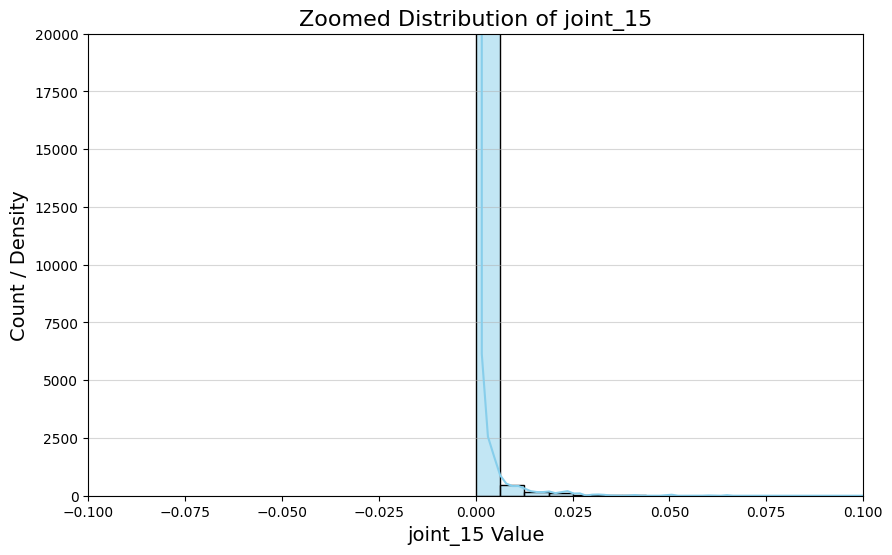

Check: Plotting joint_16


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


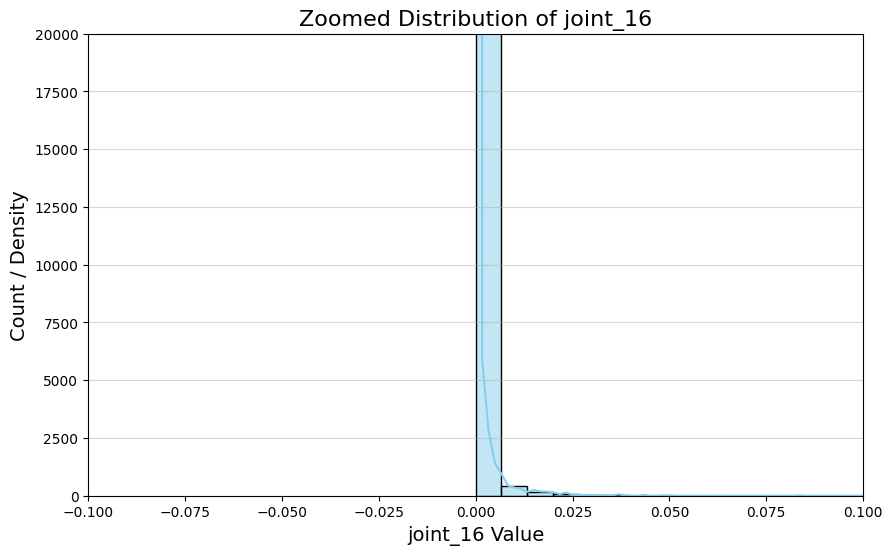

Check: Plotting joint_17


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


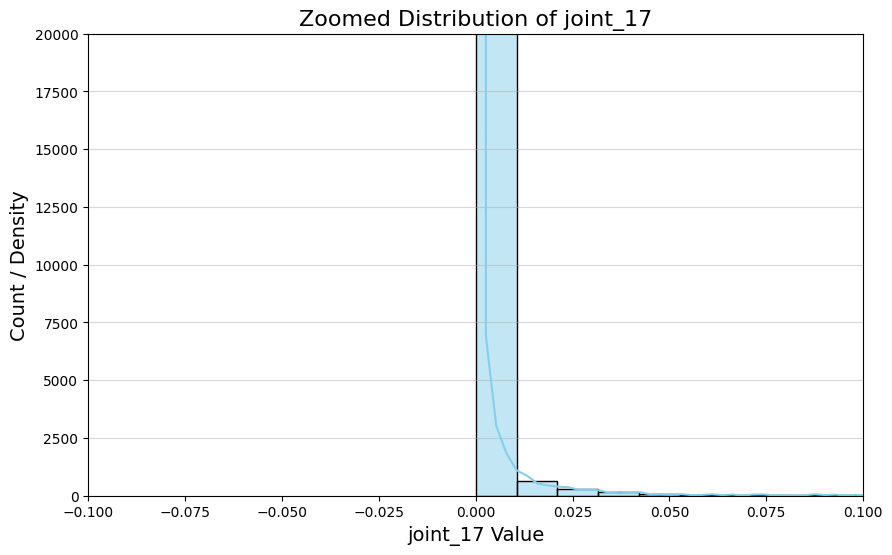

Check: Plotting joint_18


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


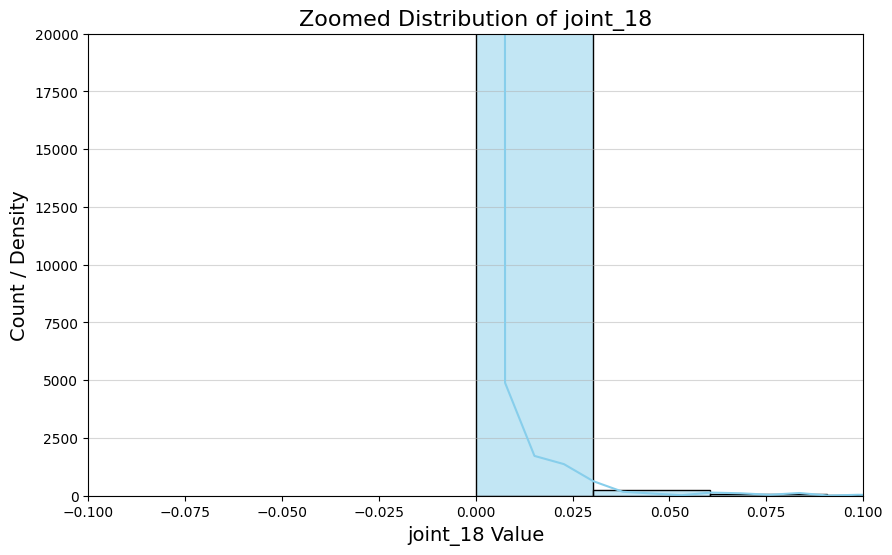

Check: Plotting joint_19


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


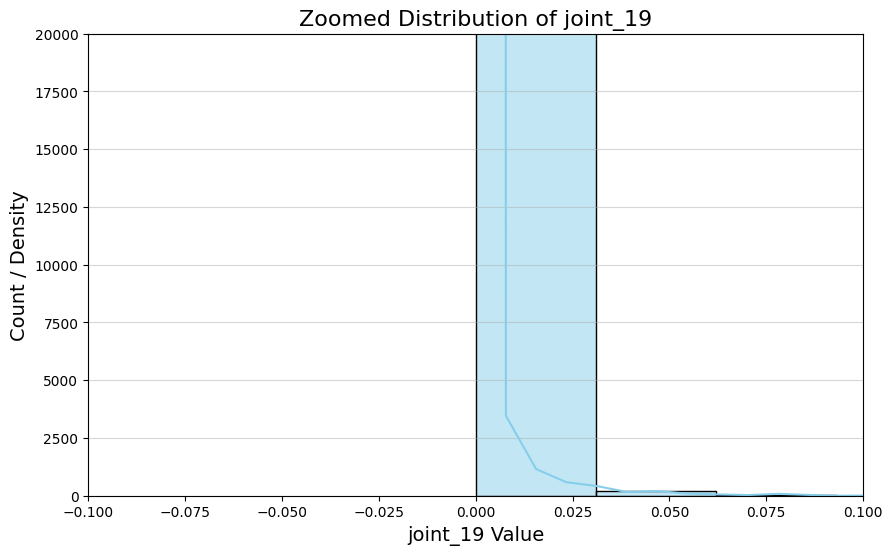

Check: Plotting joint_20


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


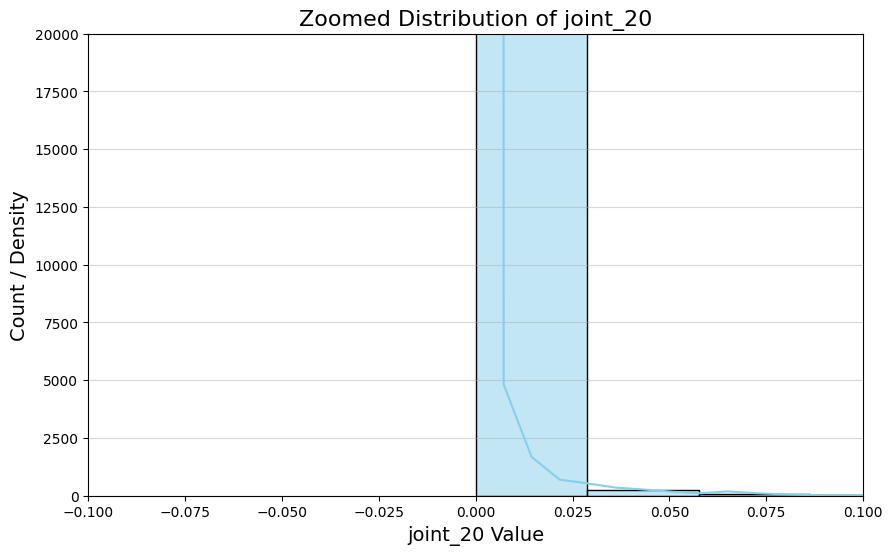

Check: Plotting joint_21


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


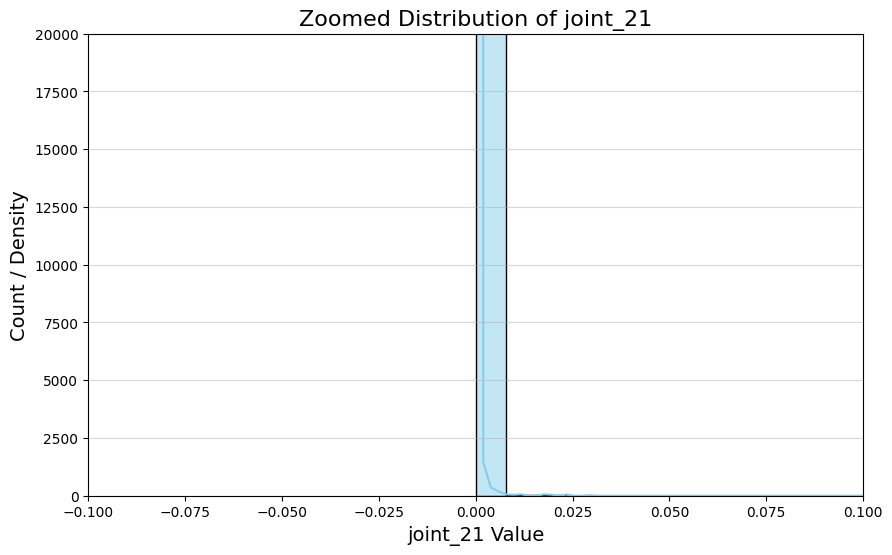

Check: Plotting joint_22


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


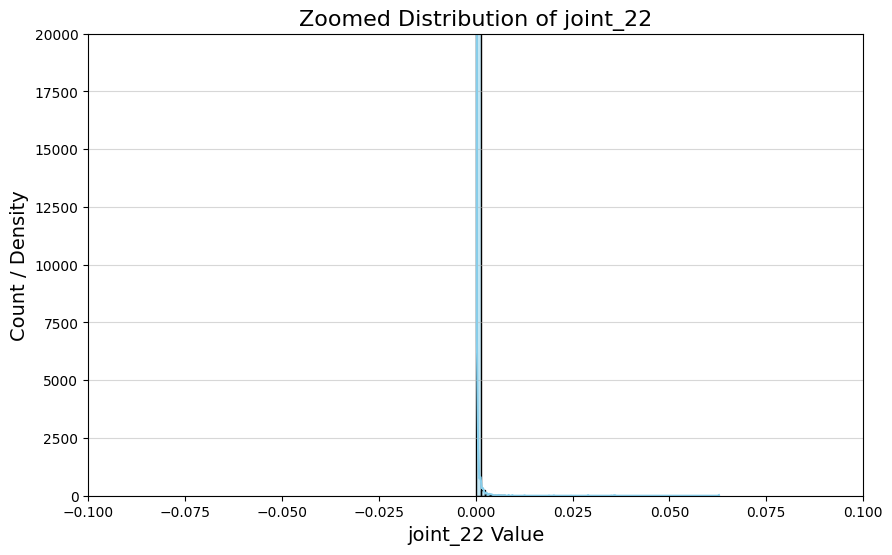

Check: Plotting joint_23


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


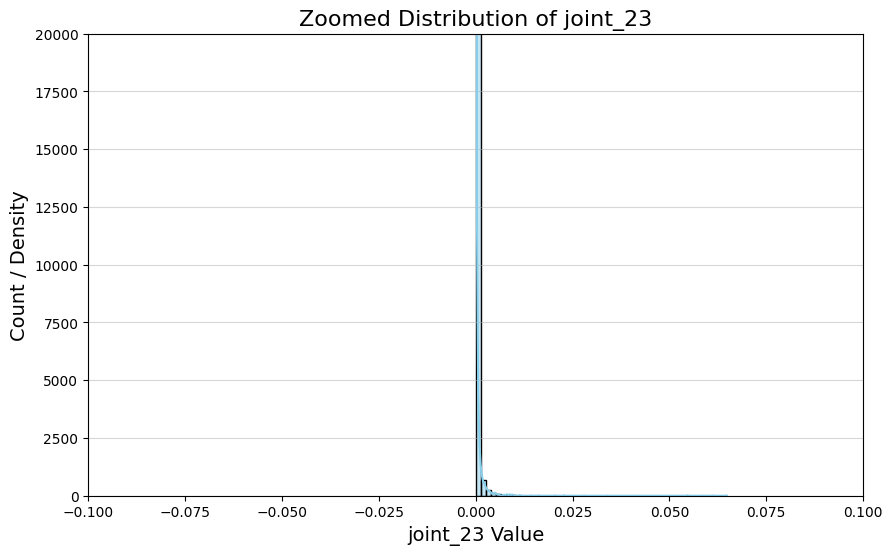

Check: Plotting joint_24


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


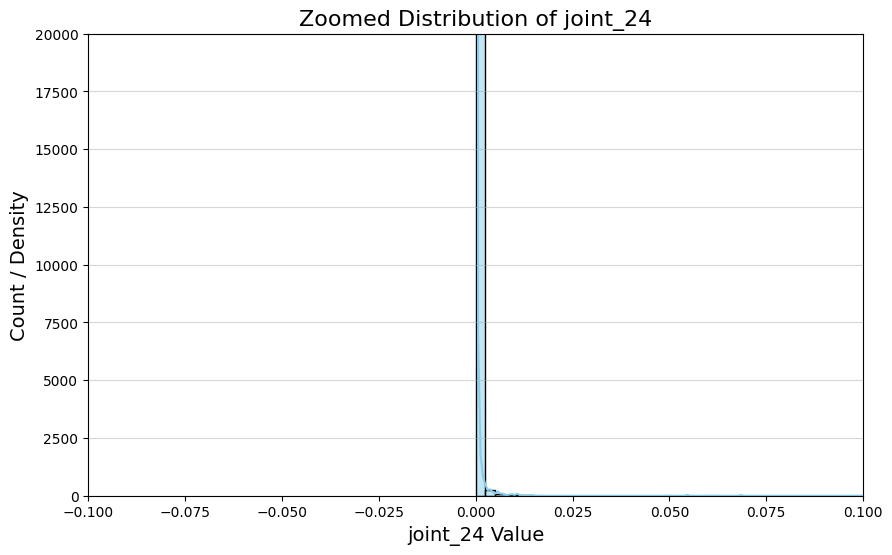

Check: Plotting joint_25


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


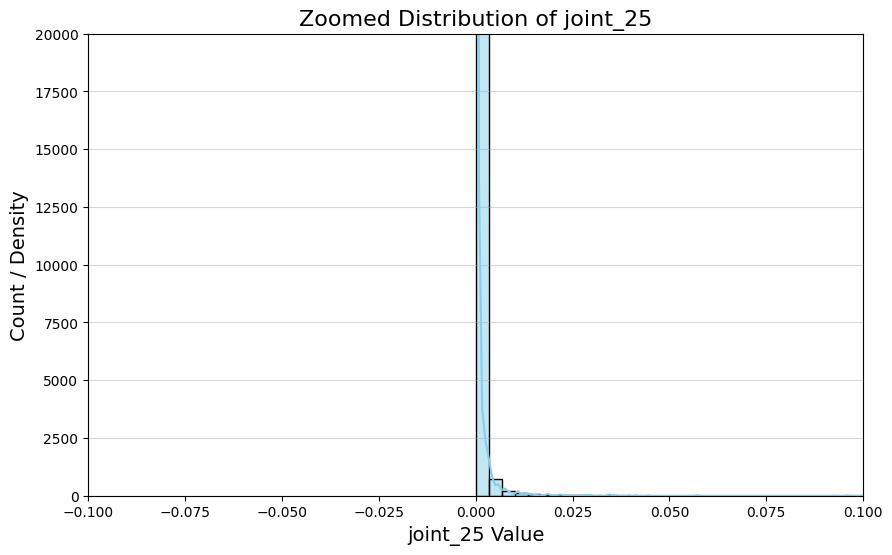

In [50]:
columns = ['joint_13', 'joint_14', 'joint_15',
       'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21',
       'joint_22', 'joint_23', 'joint_24', 'joint_25']

plot_zoomed_distributions_notebook(
    df=dataset, 
    columns_to_plot=columns, 
    zoom_limit=0.05
)

In [67]:
def print_outlier(dataset: pd.DataFrame, columns: List[str]):
    """
    Identifies and prints the actual values in specified columns that are greater than 0.1.
    
    Args:
        dataset (pd.DataFrame): The input DataFrame.
        columns (List[str]): A list of column names to check for outliers.
    """
    for col in columns:
        if col in dataset.columns:
            is_outside_range = dataset[col] > 0.1
            
            outlier_values = dataset.loc[is_outside_range, col]
            
            count = len(outlier_values)
            print(f"\n--- Column: '{col}' ({count} values > 0.1) ---")
            
            if count > 0:
                print(outlier_values.to_string())
            else:
                print("No values found > 0.1")
            
        else:
            print(f"Warning: Column '{col}' not found in the dataset. Skipping.")

In [68]:
print_outlier(dataset, columns)


--- Column: 'joint_13' (4 values > 0.1) ---
7300      0.103812
67536     0.170132
105489    0.103801
177404    0.170117

--- Column: 'joint_14' (2 values > 0.1) ---
67582     0.125523
177358    0.125515

--- Column: 'joint_15' (5 values > 0.1) ---
13085     0.166676
108509    0.166683
115658    0.314769
147835    0.136644
170895    0.314766

--- Column: 'joint_16' (9 values > 0.1) ---
67566     0.107560
82691     0.116458
82704     0.105263
87539     0.105281
87552     0.116473
115658    0.332519
137127    0.215169
170895    0.332521
177374    0.107562

--- Column: 'joint_17' (92 values > 0.1) ---
3360      0.105051
7027      0.182583
7029      0.114860
7031      0.241930
7033      0.139730
7034      0.137985
7035      0.383713
7037      0.233312
7038      0.271612
7039      0.389815
9141      0.185986
9214      0.124460
9219      0.109246
9255      0.142667
13085     0.322401
14369     0.115266
14375     0.197403
16611     0.153412
21765     0.185267
27839     0.174150
33107     0.14

In this moment, the final opinion is that the data from joint 13 to 25 are not useful for our case.
WIP for the future